# NIDS — Fixed & Cleaned

Changes vs. original are tagged with `# FIX:` (bug fixes) and `# MOD:` (improvements).

In [1]:
#!pip install -q git+https://github.com/Blealtan/efficient-kan.git
#!pip install -q polars kagglehub

## 1. Imports & Configuration

In [2]:
import os, gc, random, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from efficient_kan import KAN
import pandas as pd
import matplotlib.pyplot as plt
# FIX: removed duplicate `import gc` (was imported twice)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED):
    """FIX: single, complete seeding routine that can be re-invoked before each
    experiment config, so every (arch, source) run starts from an identical RNG
    state instead of inheriting whatever the previous run consumed."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False        # FIX: was never disabled

seed_everything(SEED)

def seeded_generator(seed: int = SEED) -> torch.Generator:
    """FIX: DataLoader shuffles were driven by the global RNG; give shuffling
    loaders their own seeded generator for run-to-run reproducibility."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g

############################ TO CHANGE ACROSS RUNS #############################
SPLINE_TRUE     = True

# ── Data ──────────────────────────────────────────────────────────────────────
SAMPLE_N        = 1_000_000
################################################################################
BATCH_SIZE      = 256
TTA_BATCH_SIZE  = 512        # larger batches = more stable gradient estimates

# ── Model ─────────────────────────────────────────────────────────────────────
LATENT_DIM      = 32

# ── Pre-training ──────────────────────────────────────────────────────────────
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1e-3
WEIGHT_DECAY    = 1e-4
RECON_W         = 0.5        # reconstruction regularises encoder for transfer

# ── CTTA ──────────────────────────────────────────────────────────────────────
FEW_SHOT_RATIO  = 0.0001     # fraction of target used as labelled pool
FEW_SHOT_MATCH_STEPS = False  # MOD: give the few-shot baseline the SAME number
                             # of optimizer steps as CTTA takes over the stream
                             # (previously 20 epochs = 20 steps vs CTTA's ~196
                             # — a hidden 10x step-budget advantage for CTTA in
                             # one direction and for few-shot in the other,
                             # depending on architecture). With matched steps,
                             # stream access is the ONLY difference.
AGSA_ABLATION   = True       # MOD: for KAN, rerun the headline CTTA mode with
                             # the spline gate OFF (same RNG/weights) and also
                             # record source-set F1 after adaptation — the two
                             # numbers that validate AGSA (no target cost +
                             # forgetting protection).
SCRATCH_BASELINE = True      # MOD: also run few-shot and CTTA from a RANDOM
                             # init (no source pretraining) with the same
                             # objectives and step budget, training ALL
                             # parameters — layer-selective updates on a
                             # random frozen encoder would be meaningless, so
                             # full-capacity training is the strongest honest
                             # form of this baseline. Quantifies the value of
                             # source pretraining.
MIN_POOL_SIZE   = 100        # MOD: hard floor so the pool never collapses
FEW_SHOT_W      = 1.0        # supervised CE weight during CTTA
TTA_LR          = 1e-2       # higher lr is fine — only norm params updated
TTA_STEPS       = 1
USE_ENTROPY     = True       # FIX(v1): term was silently commented out of the
                             # loss. FIX(v2): plain entropy min made CTTA worse
                             # — replaced by a robust variant (see
                             # stream_entropy_loss): confidence-filtered,
                             # confidence-weighted, and prior-anchored.
ENTROPY_W       = 1.0        # weight on the filtered entropy term
ENT_CONF_FRAC   = 0.4        # EATA-style reliability threshold: only samples
                             # with entropy < ENT_CONF_FRAC * ln(2) contribute
MARGINAL_W      = 1.0        # weight on KL(batch-mean prediction || pool
                             # prior) — anti-collapse anchor for imbalance
RECON_W_TTA     = 0.5        # reconstruction weight during CTTA
RECON_SOURCE    = 'stream'   # FIX: 'pool' recon (original) was redundant — it
                             # ran on the same ~100 samples CE already trains
                             # on every step, so it added no signal and no
                             # improvement. 'stream' turns it into TTT-style
                             # self-supervision on the unlabelled stream, where
                             # the shift actually is. Options:
                             #   'stream' | 'pool' | 'both' | 'none'
RESTORE_PROB    = 0.01       # MOD: stochastic restore (CoTTA) — after each
                             # update, each trainable weight snaps back to its
                             # source value with this probability. Bounds
                             # cumulative drift over long streams; the main
                             # defence against unsupervised collapse (the
                             # 'ent-only F1=0.01' failure). 0 disables.

# ── AGSA: Activation-Gated Spline Adaptation (NOVELTY, KAN-only) ──────────────
# KAN spline coefficients are LOCAL: each B-spline basis governs one region of
# an input's range. Coefficients of regions the target stream never visits get
# near-zero (pure-noise) gradients — but Adam's per-parameter normalisation
# amplifies them into full-size updates, silently corrupting the learned
# function exactly where the target provides no evidence. AGSA tracks which
# basis functions target data actually activates (EMA over stream + pool
# forwards) and hard-masks gradients for dormant coefficients: adaptation is
# confined to regions the target exercises, source knowledge elsewhere is
# structurally frozen. Architecture-intrinsic retention — no penalty term, no
# extra loss, no effect on visited-region fitting.
USE_SPLINE_GATE   = True
SPLINE_GATE_EMA   = 0.99     # EMA horizon for basis-activation mass
SPLINE_GATE_THRESH = 0.05    # coefficient is 'active' if its EMA mass exceeds
                             # this fraction of the max mass on that input dim
EWC_LAMBDA      = 0.0        # MOD/FIX: KAN_Retention (EWC) was computed but its
                             # penalty was NEVER added to the CTTA loss. Set > 0
                             # (e.g. 100.0) to actually apply retention.

# ── Loss (MOD: class imbalance) ───────────────────────────────────────────────
# 'ce'          : plain CrossEntropy (original behaviour)
# 'weighted_ce' : CrossEntropy with inverse-frequency class weights, computed
#                 from whatever labelled data trains each phase (source train
#                 split for pretraining, labelled pool for CTTA / few-shot)
# 'focal'       : Focal loss (Lin et al. 2017) with per-class alpha from the
#                 same inverse-frequency weights + focusing parameter gamma
LOSS_TYPE        = 'weighted_ce'
FOCAL_GAMMA      = 2.0
MAX_CLASS_WEIGHT = 20.0      # cap — a 100-sample pool with ~3 attacks would
                             # otherwise produce weights >16 and destabilise
                             # CTTA's already-high learning rate

# ── Scaling (MOD: transfer-friendly scaling) ──────────────────────────────────
# 'minmax'   : MinMaxScaler(-1, 1) + clip                (original behaviour)
# 'robust'   : median/IQR scaling; ±ROBUST_CLIP scaled units map to ±1, clip
# 'quantile' : rank-based QuantileTransformer -> uniform [-1, 1]. Immune to
#              heavy tails, and out-of-distribution target values saturate
#              gracefully at the grid boundary instead of a whole feature
#              collapsing when the source min/max doesn't cover target range
SCALER_TYPE = 'quantile'
ROBUST_CLIP = 4.0            # only used when SCALER_TYPE == 'robust'

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def log_step(step_num: int, step_name: str):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"\n\033[36m[{timestamp}]\033[96m [Step {step_num}]\033[0m {step_name}")
log_step(1,f'Configuration')
print(f'[System] Seed={SEED} | Device={device} [System] Loss={LOSS_TYPE} | Scaler={SCALER_TYPE}')

/home/seyyed/projects/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[2026-07-24 08:18:55] [Step 1] Configuration
[System] Seed=42 | Device=cuda [System] Loss=weighted_ce | Scaler=quantile


## 1b. Scaling & imbalance-aware losses (MOD)

In [3]:
from sklearn.preprocessing import RobustScaler, QuantileTransformer

class FeatureScaler:
    """
    MOD: pluggable scaling strategy behind the same fit/transform interface the
    rest of the pipeline already uses, so it drops in wherever a MinMaxScaler
    was passed around. Every mode guarantees float32 output in [-1, 1], which
    the KAN grid_range=[-1, 1] requires.

    'minmax'   — exactly the original behaviour (MinMax to [-1,1], then clip).
    'robust'   — (x - median) / IQR per feature; ±ROBUST_CLIP scaled units map
                 to ±1 and everything beyond clips. Outliers no longer define
                 the range, so the bulk of the data keeps its resolution.
    'quantile' — rank-based map to uniform [0,1] rescaled to [-1,1]. Fully
                 immune to heavy tails; out-of-range target values saturate at
                 the boundary instead of compressing the whole feature. This is
                 the transfer-friendliest option: when the source scaler is
                 reused on a shifted target, minmax can push a large share of a
                 feature onto the clip boundary, while quantile degrades softly.
    """
    def __init__(self, kind: str = SCALER_TYPE):
        if kind not in ('minmax', 'robust', 'quantile'):
            raise ValueError(f"Unknown SCALER_TYPE={kind!r}. "
                             f"Choose 'minmax', 'robust', or 'quantile'")
        self.kind = kind
        self._sk = None

    def fit(self, X):
        if self.kind == 'minmax':
            self._sk = MinMaxScaler(feature_range=(-1, 1)).fit(X)
        elif self.kind == 'robust':
            self._sk = RobustScaler(quantile_range=(5.0, 95.0)).fit(X)
        else:  # quantile
            self._sk = QuantileTransformer(
                output_distribution='uniform',
                n_quantiles=min(1000, len(X)),   # n_quantiles must be <= n_samples
                subsample=1_000_000,
                random_state=SEED,
            ).fit(X)
        return self

    def transform(self, X):
        if self._sk is None:
            raise RuntimeError('FeatureScaler.transform called before fit')
        Z = self._sk.transform(X)
        if self.kind == 'robust':
            Z = Z / ROBUST_CLIP                  # ±ROBUST_CLIP IQR-units -> ±1
        elif self.kind == 'quantile':
            Z = Z * 2.0 - 1.0                    # [0,1] -> [-1,1]
        return np.clip(Z, -1, 1).astype(np.float32)


def compute_class_weights(y) -> torch.Tensor:
    """
    MOD: inverse-frequency ('balanced') weights, w_c = N / (n_classes * N_c),
    capped at MAX_CLASS_WEIGHT. Accepts a numpy array or a torch tensor.
    Falls back to uniform weights if a class is absent (can happen in a tiny
    pool) so the criterion never divides by zero.
    """
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()
    y = np.asarray(y)
    counts = np.bincount(y, minlength=2).astype(np.float64)
    if (counts == 0).any():
        print('   [class weights] WARNING: a class is missing from the labelled '
              'data — falling back to uniform weights.')
        return torch.ones(2, dtype=torch.float32)
    w = len(y) / (2.0 * counts)
    w = np.minimum(w, MAX_CLASS_WEIGHT)
    return torch.tensor(w, dtype=torch.float32)


class FocalLoss(nn.Module):
    """
    MOD: Focal loss (Lin et al., 2017) for class-imbalanced classification.
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha is a per-class weight tensor (here: the same inverse-frequency
    weights as 'weighted_ce'); gamma down-weights easy examples so training
    focuses on the hard minority. Reduces to alpha-weighted CE at gamma=0.
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma
        # registered as a buffer so .to(device) moves it with the module
        self.register_buffer('alpha',
                             alpha if alpha is not None else torch.ones(2))

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        log_pt    = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt        = log_pt.exp()
        alpha_t   = self.alpha.to(logits.device)[targets]
        loss      = -alpha_t * (1.0 - pt) ** self.gamma * log_pt
        return loss.mean()


def make_criterion(y, device) -> nn.Module:
    """
    MOD: build the classification criterion according to LOSS_TYPE, with class
    statistics taken from the labelled data actually used in that phase
    (source train split for pretraining; labelled pool for CTTA and the
    few-shot baseline). Centralised so every training path stays consistent.
    """
    if LOSS_TYPE == 'ce':
        return nn.CrossEntropyLoss()
    weights = compute_class_weights(y).to(device)
    if LOSS_TYPE == 'weighted_ce':
        print(f'   [criterion] weighted CE | weights='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return nn.CrossEntropyLoss(weight=weights)
    if LOSS_TYPE == 'focal':
        print(f'   [criterion] focal (gamma={FOCAL_GAMMA}) | alpha='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return FocalLoss(alpha=weights, gamma=FOCAL_GAMMA).to(device)
    raise ValueError(f"Unknown LOSS_TYPE={LOSS_TYPE!r}. "
                     f"Choose 'ce', 'weighted_ce', or 'focal'")


def labels_of(loader) -> torch.Tensor:
    """MOD: pull the label tensor back out of a TensorDataset-backed loader so
    criteria can be built from exactly the data a phase trains on."""
    return loader.dataset.tensors[1]


def reset_loader_generator(loader, seed: int = SEED):
    """
    FIX: shuffling DataLoaders carry their own dedicated torch.Generator,
    which torch.get_rng_state()/set_rng_state() do NOT cover — those only
    snapshot the global RNG. Every 'identical RNG' guarantee (dual-mode CTTA,
    few-shot isolation, ablation restore, AGSA on/off) therefore silently
    excluded pool shuffling. Re-seeding the loader's generator at the start of
    each comparable run makes every run see the identical shuffle sequence by
    construction, independent of what ran before it.
    """
    g = getattr(loader, 'generator', None)
    if g is not None:
        g.manual_seed(seed)


def reseed_loader(loader, seed: int = SEED):
    """FIX: shuffling DataLoaders carry a PRIVATE generator whose state
    advances across runs — torch.set_rng_state does NOT reset it. Without this,
    'matched-RNG' comparisons (spline vs full CTTA, AGSA on vs off, baselines)
    silently saw different pool orderings. Called at the start of every
    adaptation routine so each run consumes an identical shuffle sequence."""
    gen = getattr(loader, 'generator', None)
    if gen is not None:
        gen.manual_seed(seed)


def pool_prior(loader, device) -> torch.Tensor:
    """
    MOD: class prior estimated from the labelled pool. Because the pool is a
    stratified sample of the target, its attack rate is an unbiased estimate
    of the stream's — the one piece of distributional knowledge CTTA is
    legitimately allowed to use. Clamped away from 0 so the KL term below is
    always finite.
    """
    y = labels_of(loader).cpu().numpy()
    r = float(np.mean(y))
    prior = torch.tensor([1.0 - r, r], dtype=torch.float32, device=device)
    return prior.clamp_min(1e-3)


def stream_entropy_loss(logits_s, prior):
    """
    FIX: robust replacement for plain entropy minimisation, which degraded
    CTTA. Plain entropy min fails in two documented ways:

      (1) noisy gradients from unreliable samples — high-entropy predictions
          sit near the decision boundary, and pushing them to be confident in
          whatever direction they currently lean amplifies errors
          (Niu et al. 2022, EATA).
      (2) majority-class collapse — unconstrained confidence maximisation on
          an imbalanced stream is minimised by predicting 'benign' for
          everything, silently destroying attack recall.

    Remedies, applied together:
      - reliability filter: only samples with entropy below
        E0 = ENT_CONF_FRAC * ln(2) contribute (ln(2) = max binary entropy);
      - confidence weighting: contributions scaled by exp(E0 - e), so the
        most confident samples dominate (EATA's weighting);
      - prior anchor: KL(batch-mean prediction || pool prior) penalises drift
        of the predicted class ratio away from the pool's attack rate. This
        replaces SHOT-style marginal-entropy 'diversity', whose implicit
        balanced-classes assumption is wrong for NIDS (a 50/50 pull on a 3%%
        attack stream is itself a collapse pressure, just toward the middle).

    Returns a scalar loss (0 contribution from the entropy term if no sample
    passes the filter — the KL anchor is always active).
    """
    E0 = ENT_CONF_FRAC * float(np.log(2.0))
    log_probs = F.log_softmax(logits_s, dim=1)
    probs     = log_probs.exp()
    ent       = -(probs * log_probs).sum(dim=1)

    mask = ent < E0
    if mask.any():
        w = torch.exp(E0 - ent[mask]).detach()   # EATA weights — no grad through w
        loss_ent = (w * ent[mask]).sum() / w.sum()
    else:
        loss_ent = logits_s.new_zeros(())

    p_bar   = probs.mean(dim=0).clamp_min(1e-8)
    loss_kl = (p_bar * (p_bar / prior).log()).sum()

    return ENTROPY_W * loss_ent + MARGINAL_W * loss_kl


class StochasticRestore:
    """
    MOD: CoTTA-style stochastic restore (Wang et al. 2022). After each
    optimizer step, every element of every trainable tensor is reset to its
    source (post-pretrain) value with probability RESTORE_PROB.

    Why: over a ~1M-sample stream (~2000 updates) small per-step errors
    compound — the dominant failure of unsupervised objectives (the entropy-
    only 'F1 = 0.01' collapse), and a latent risk even for anchored CTTA.
    Stochastic restore makes total drift mean-reverting toward the source
    weights without freezing anything, and unlike a hard periodic reset it
    never discards adaptation wholesale. Applied identically to every config
    (headline run + all ablation rows) so comparability is preserved.
    """
    def __init__(self, params, prob: float = RESTORE_PROB):
        self.prob   = float(prob)
        self.params = list(params)
        self.source = [p.data.clone() for p in self.params]

    @torch.no_grad()
    def __call__(self):
        if self.prob <= 0:
            return
        for p, s in zip(self.params, self.source):
            mask = torch.rand_like(p) < self.prob
            p.data[mask] = s[mask]


class SplineActivationGate:
    """
    NOVELTY — Activation-Gated Spline Adaptation (AGSA). KAN-specific TTA.

    Mechanism:
      * a forward pre-hook on a KANLinear layer captures its input on every
        forward pass — including the label-free predict pass, so the
        activation statistics come for free, with zero extra compute;
      * the layer's own b_splines() gives per-(input-dim, coefficient) basis
        activation; an EMA accumulates this 'visitation mass' over the stream;
      * a gradient hook on spline_weight zero-masks coefficients whose mass is
        below SPLINE_GATE_THRESH of the per-dim maximum.

    Why it can't hurt visited regions: for active coefficients the gradient is
    passed through unchanged. Why it protects the rest: dormant coefficients
    receive only basis-tail noise, which Adam would renormalise into full-size
    updates — the gate cuts that path entirely, so the function outside the
    target's support stays exactly at its source shape (retention by
    architecture rather than by penalty; complements or replaces EWC).

    Warm-up: until the first mass estimate exists, gradients pass ungated.
    Call remove() when done; coverage() reports the adapted fraction and
    mask() can be visualised as an adapted-vs-frozen heatmap per input dim.
    """
    def __init__(self, layer, ema: float = SPLINE_GATE_EMA,
                 thresh: float = SPLINE_GATE_THRESH):
        if not (hasattr(layer, 'b_splines') and hasattr(layer, 'spline_weight')):
            raise ValueError('SplineActivationGate needs an efficient-kan '
                             'KANLinear-style layer (b_splines + spline_weight).')
        self.layer  = layer
        self.ema    = float(ema)
        self.thresh = float(thresh)
        self.mass   = None      # (in_features, n_coeff) EMA of |basis|
        # NOVELTY (cumulative AGSA): coefficients owned by previously-adapted
        # domains. None until freeze_current() is called; once set, these
        # coefficients receive zero gradient in all later stages, partitioning
        # the spline support across a domain sequence.
        self.protected = None
        # capture switch: external (cumulative) gates stay attached across a
        # whole domain sequence, including evaluation passes on OTHER domains;
        # capture is enabled only while the current adaptation stage runs so
        # the mass reflects the current domain, not the evaluation traffic.
        self.capture = True
        self._h_in   = layer.register_forward_pre_hook(self._capture)
        self._h_grad = layer.spline_weight.register_hook(self._gate)

    def _capture(self, module, inputs):
        if not self.capture:
            return
        x = inputs[0]
        if x.dim() != 2:                      # defensive: expect (batch, in)
            return
        with torch.no_grad():
            b = module.b_splines(x.detach()).abs().mean(dim=0)  # (in, n_coeff)
            self.mass = b if self.mass is None \
                        else self.ema * self.mass + (1.0 - self.ema) * b

    def mask(self):
        if self.mass is None:
            return None
        ref = self.mass.max(dim=-1, keepdim=True).values.clamp_min(1e-12)
        return (self.mass > self.thresh * ref).to(self.layer.spline_weight.dtype)

    def _gate(self, grad):
        m = self.mask()
        allow = m                              # activation-localised updates
        if self.protected is not None:
            # NOVELTY (cumulative AGSA): zero gradient on coefficients owned
            # by earlier domains in the sequence, regardless of whether the
            # current domain also activates them.
            keep = (~self.protected).to(grad.dtype)
            allow = keep if allow is None else allow * keep
        if allow is None:
            return grad                        # warm-up: ungated
        # spline_weight: (out, in, n_coeff); allow: (in, n_coeff) — broadcast
        return grad * allow.unsqueeze(0)

    def freeze_current(self) -> float:
        """
        NOVELTY (cumulative AGSA): call at the END of a domain's adaptation
        stage. Folds the current domain's activation mask into the protected
        set (union) and resets the mass EMA so the next stage measures the
        next domain's activations from scratch. Returns the protected
        fraction — the share of spline coefficients now owned by past domains.

        NOTE: exact freezing of protected coefficients requires a FRESH
        optimizer for the next stage — a reused Adam would keep moving them
        via leftover momentum despite zero gradients (the same per-parameter
        pathology AGSA targets). run_ctta constructs a new optimizer on every
        call, so the sequential protocol satisfies this by construction.
        """
        m = self.mask()
        if m is not None:
            mb = m.bool()
            self.protected = mb if self.protected is None else (self.protected | mb)
        self.mass = None
        return 0.0 if self.protected is None else float(self.protected.float().mean())

    def coverage(self) -> float:
        m = self.mask()
        return float('nan') if m is None else float(m.mean())

    def remove(self):
        self._h_in.remove()
        self._h_grad.remove()

In [4]:
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            # FIX: clip at 0 — corrupted flows with end < start produced negative
            # durations, and log1p(x < -1) = NaN downstream.
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS'))
            .clip(lower_bound=0).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    # FIX: BYTES_PER_PKT was created but never log-transformed although it is as
    # heavy-tailed as the columns it is derived from. Also clip all log inputs
    # at 0 to guarantee log1p never sees values < -1.
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'BYTES_PER_PKT',
                'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).clip(lower_bound=0).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    # FIX: keep only numeric columns. The original called .to_numpy().astype
    # (float32) on whatever remained — any stray string/categorical column in a
    # dataset variant crashed the run (or worse, silently produced garbage).
    numeric = [c for c, dt in zip(df.columns, df.dtypes) if dt.is_numeric()]
    dropped = [c for c in df.columns if c not in numeric]
    if dropped:
        print(f'   [engineer_features] Dropping non-numeric columns: {dropped}')
    return df.select(numeric)


def align_features(df: pl.DataFrame, reference_features: list) -> pl.DataFrame:
    """FIX (critical): the original code assumed source and target datasets had
    identical feature columns in identical ORDER. `scaler.transform` and the
    model consume a bare NumPy matrix, so any order mismatch silently fed
    feature i of the target into the slot learned for feature j of the source.
    This reindexes the target to the source schema: shared columns are
    reordered, missing ones are zero-filled (with a warning), extras dropped."""
    missing = [c for c in reference_features if c not in df.columns]
    extra   = [c for c in df.columns if c not in reference_features]
    if missing:
        print(f'   [align_features] WARNING: target missing {len(missing)} source '
              f'features (zero-filled): {missing}')
        df = df.with_columns([pl.lit(0.0, dtype=pl.Float32).alias(c) for c in missing])
    if extra:
        print(f'   [align_features] Dropping {len(extra)} target-only features: {extra}')
    return df.select(reference_features)


def load_dataset(dataset_name: str, sample_n: int = None, align_to: list = None):
    """Download dataset and return (X, y, feature_names). Uses random sampling.

    FIX: the original read only csv_files[0] — an arbitrary file from os.walk —
    and silently ignored every other CSV in multi-file datasets. All CSVs are
    now concatenated (vertical_relaxed handles dtype drift between files).
    """
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = sorted(
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    )
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found under {path}')
    frames = [pl.scan_csv(f) for f in csv_files]
    df = pl.concat(frames, how='vertical_relaxed').collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=SEED)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    # FIX: warn instead of silently fabricating an all-benign label vector.
    if label_col is None:
        print("   WARNING: no 'label' column found — y set to all zeros; "
              "F1 on this dataset is meaningless.")
        y = np.zeros(df.height, dtype=np.int64)
    else:
        y = df[label_col].to_numpy().astype(np.int64)
    df = engineer_features(df)
    if align_to is not None:
        df = align_features(df, align_to)          # FIX: schema alignment
    feature_names = df.columns
    X = df.to_numpy().astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y, feature_names


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on the training split only.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    # MOD: pluggable scaling strategy (SCALER_TYPE). FeatureScaler.transform
    # already returns float32 clipped to [-1, 1] in every mode.
    scaler = FeatureScaler(SCALER_TYPE).fit(X_tr)
    X_tr   = scaler.transform(X_tr)
    X_te   = scaler.transform(X_te)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           generator=seeded_generator())      # FIX: seeded shuffle
    loader_te = DataLoader(test_ds,  batch_size=TTA_BATCH_SIZE, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y, external_scaler=None):
    """
    Split the target into a small labelled pool and an unlabelled-at-adaptation
    stream (labels kept for evaluation only).

    FIX (docstring): the original docstring claimed 'Fit a fresh MinMaxScaler on
    the full target dataset' but the code (a) fitted on the pool only, and (b)
    was always called with the SOURCE scaler anyway. The behaviour is now stated
    honestly: if external_scaler is given it is used (deployment-realistic — no
    target statistics assumed); otherwise a scaler is fitted on the pool only,
    which is the only data an analyst would have labelled/inspected.

    The pool represents a brief initial analyst review period at deployment.
    """
    # FIX: with FEW_SHOT_RATIO=1e-4 the pool size depends entirely on SAMPLE_N
    # and can drop below the point where stratification is even possible
    # (train_test_split raises if the minority class has < 2 members, and the
    # 'both classes preserved' claim in the old comment was not guaranteed).
    pool_n = max(int(round(len(y) * FEW_SHOT_RATIO)), MIN_POOL_SIZE)
    X_pool, X_stream, y_pool, y_stream = train_test_split(
        X, y,
        train_size=pool_n,
        random_state=SEED,
        stratify=y,
    )
    if y_pool.sum() < 2:
        print(f'   WARNING: pool contains only {int(y_pool.sum())} attack '
              f'sample(s); supervised anchoring will be very weak.')

    # MOD: pluggable scaling strategy (SCALER_TYPE) via FeatureScaler.
    scaler   = external_scaler if external_scaler is not None \
               else FeatureScaler(SCALER_TYPE).fit(X_pool)

    X_pool   = scaler.transform(X_pool)
    X_stream = scaler.transform(X_stream)

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds, batch_size=BATCH_SIZE, shuffle=True,
                               generator=seeded_generator())   # FIX: seeded shuffle
    stream_loader = DataLoader(stream_ds, batch_size=TTA_BATCH_SIZE, shuffle=False)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader

## 2. Models

In [5]:
class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2                (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z


class TabTransformerAEClassifier(nn.Module):
    """
    Shared TabTransformer encoder → classifier head + decoder head.
    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                 n_heads: int = 4, d_token: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.d_token   = d_token
        self.feature_proj = nn.Linear(1, d_token, bias=False)
        self.feature_bias = nn.Parameter(torch.randn(input_dim, d_token) * 0.02)
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4), nn.GELU(),
            nn.Linear(d_token * 4, d_token),
        )
        self.encoder_out = nn.Linear(d_token, latent_dim)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, d_token),
            nn.LayerNorm(d_token), nn.GELU(),
            nn.Linear(d_token, input_dim),
        )

    def forward(self, x):
        tokens = self.feature_proj(x.unsqueeze(-1)) + self.feature_bias.unsqueeze(0)
        tokens = self.ln1(tokens)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = tokens + attn_out
        tokens = self.ln2(tokens)
        tokens = tokens + self.ffn(tokens)
        pooled = tokens.mean(dim=1)
        z = self.ln(self.encoder_out(pooled))
        return self.classifier(z), self.decoder(z), z


class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.

    NOTE (design, unchanged): Conv1d with kernel_size=1 over a length-1
    sequence is mathematically identical to a Linear layer — the 'CNN' baseline
    is really an MLP with GroupNorm. Kept as-is for continuity with prior runs,
    but be aware of this when describing it in a paper.
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'tab':
        return TabTransformerAEClassifier(input_dim, LATENT_DIM)
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'tab'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.

    Updated: all LayerNorm/GroupNorm params (outside decoder), classifier head,
    last encoder layer. Frozen: early encoder layers, decoder.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen:
            seen.add(id(p))
            params.append(p)

    for name, module in model.named_modules():
        if 'decoder' in name:
            continue
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    for p in model.classifier.parameters():
        add(p)

    if isinstance(model, KanAEClassifier):
        if hasattr(model.encoder, 'layers') and len(model.encoder.layers) > 0:
            for p in model.encoder.layers[-1].parameters():
                add(p)
    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                add(p)
    elif isinstance(model, TabTransformerAEClassifier):
        for p in model.encoder_out.parameters():
            add(p)

    return params

## 3. KAN Retention (EWC)

In [6]:
class KAN_Retention:
    """
    KAN-specific Elastic Weight Consolidation (EWC).

    FIX (major, semantic): in the original notebook the Fisher matrix and
    penalty were computed, but penalty() was only *printed after* CTTA — it was
    never added to any loss, so it never 'penalized drastic changes during
    CTTA' as the docstring claimed. run_ctta now accepts (ewc, ewc_lambda) and
    applies the penalty when EWC_LAMBDA > 0.
    """
    def __init__(self, model, dataloader, device, params_to_protect):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.params_to_protect = params_to_protect

        self.optpar_dict = {id(p): p.data.clone().detach()
                            for p in self.params_to_protect}

        print('[KAN Retention] Computing Fisher Information on Source Data...')
        self.fisher_dict = self._compute_fisher()
        print('[KAN Retention] Initialization Complete.')

    def _compute_fisher(self):
        fisher_dict = {id(p): torch.zeros_like(p.data) for p in self.params_to_protect}
        # FIX: remember and restore requires_grad flags — the original left
        # requires_grad=True on protected params as a side effect, leaking
        # state into whatever ran next.
        prev_flags = {id(p): p.requires_grad for p in self.params_to_protect}
        for p in self.params_to_protect:
            p.requires_grad_(True)

        was_training = self.model.training
        self.model.eval()
        # MOD: compute Fisher under the same imbalance-aware criterion used in
        # training, so parameter importance reflects the actual loss landscape.
        ce_crit = make_criterion(labels_of(self.dataloader), self.device)

        num_samples = 0
        for x, y in self.dataloader:
            x, y = x.to(self.device), y.to(self.device)
            self.model.zero_grad()
            logits, _, _ = self.model(x)
            loss = ce_crit(logits, y)
            loss.backward()
            for p in self.params_to_protect:
                if p.grad is not None:
                    fisher_dict[id(p)] += (p.grad.data ** 2) * x.size(0)
            num_samples += x.size(0)

        for p in self.params_to_protect:
            fisher_dict[id(p)] /= max(num_samples, 1)
            p.requires_grad_(prev_flags[id(p)])
        self.model.zero_grad(set_to_none=True)     # FIX: don't leave stale grads
        if was_training:
            self.model.train()
        return fisher_dict

    def penalty(self):
        """EWC penalty: sum( Fisher * (theta - theta_source)^2 )."""
        loss = torch.tensor(0.0, device=self.device)   # FIX: was a Python float;
        # starting from a tensor keeps the return type consistent whether or
        # not any parameter contributes, and keeps it on the right device.
        for p in self.params_to_protect:
            fisher = self.fisher_dict[id(p)]
            optpar = self.optpar_dict[id(p)]
            loss = loss + (fisher * (p - optpar) ** 2).sum()
        return loss

## 4. Training / Evaluation

In [7]:
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + RECON_W * MSE(recon, x)
    """
    optimizer = optim.Adam(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    # MOD: imbalance-aware criterion (LOSS_TYPE) built from the labels of the
    # source training split — the exact data this phase trains on.
    ce_crit   = make_criterion(labels_of(loader), device)
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total, n_batches = 0.0, 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + RECON_W * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                # FIX: a single NaN batch used to be added to total_loss,
                # turning the reported epoch loss into NaN permanently.
                total_loss += loss.item()
                n_batches  += 1
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/max(n_batches,1):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    was_training = model.training      # FIX: restore mode instead of leaving eval
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    if was_training:
        model.train()
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1


def get_spline_only_params(model):
    """
    Minimal-parameter trainable set for CTTA, per architecture.
    KAN: only spline_weight (+ spline_scaler) of the last encoder layer.
    CNN/Tab: last encoder projection ('last-layer-only' semantics).
    """
    params = []

    if isinstance(model, KanAEClassifier):
        if not hasattr(model.encoder, 'layers') or len(model.encoder.layers) == 0:
            return []
        last = model.encoder.layers[-1]
        if hasattr(last, 'spline_weight') and isinstance(last.spline_weight, torch.nn.Parameter):
            params.append(last.spline_weight)
        if hasattr(last, 'spline_scaler') and isinstance(last.spline_scaler, torch.nn.Parameter):
            params.append(last.spline_scaler)

    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            params.extend(last_layer.parameters())

    elif isinstance(model, TabTransformerAEClassifier):
        params.extend(model.encoder_out.parameters())

    return params


def run_ctta(model, stream_loader, pool_loader, device, spline_only=False,
             ewc=None, ewc_lambda=0.0, spline_gate=None,
             train_all=False, restore_prob=None,
             prior=None, external_gates=None):
    """
    Few-Shot Layer-Selective CTTA.

    Evaluation protocol — PREDICT-THEN-ADAPT (MOD): each incoming stream batch
    is first predicted with the current model (adapted on all *previous*
    batches only), and only then used for adaptation. This is the standard
    online TTA protocol (TENT et al.): reported F1 is the performance a
    deployed system would actually have delivered, and the model never gets a
    transductive peek at the batch it is being scored on.

    Per stream batch:
      0. Predict with the current model — these predictions are what's scored
      1. Supervised CE on pool batch — anchors decision boundary to target
      2. (USE_ENTROPY) robust entropy objective on the stream batch —
         confidence-filtered + confidence-weighted entropy, plus a
         KL(batch marginal || pool prior) anti-collapse anchor.
      3. Reconstruction (RECON_SOURCE) — FIX: default moved from pool to
         stream. Pool recon ran on the same ~100 samples CE already fits every
         step (redundant — observed to give no improvement); stream recon is
         TTT-style self-supervision on the unlabelled shifted data, matching
         the pretraining objective (which reconstructed all samples).
      4. (ewc_lambda>0) EWC retention penalty toward source weights
      5. Stochastic restore (RESTORE_PROB) — MOD: CoTTA-style anti-drift;
         see StochasticRestore.

    Returns (preds, labels, trajectory) on the stream.
    """
    if train_all:
        # MOD: scratch-baseline mode — every parameter trains (a random frozen
        # encoder under layer-selective updates would be meaningless).
        train_params = list(model.parameters())
        print('[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).')
    elif spline_only:
        train_params = get_spline_only_params(model)
        print('[CTTA] SPLINE-ONLY mode: updating only last encoder layer spline weights.')
    else:
        train_params = get_trainable_params(model)

    # FIX: guard — Adam raises an opaque error on an empty parameter list
    # (possible if a KAN build lacks the expected spline attributes).
    if len(train_params) == 0:
        raise RuntimeError('run_ctta: no trainable parameters were selected — '
                           'check get_spline_only_params for this architecture.')

    trainable_ids = {id(p) for p in train_params}
    for p in model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    print(f'[CTTA] Updating {len(train_params)} param tensors '
          f'({sum(p.numel() for p in train_params)} params). '
          f'All other weights frozen.')

    optimizer = optim.Adam(train_params, lr=TTA_LR)
    # MOD: imbalance-aware criterion (LOSS_TYPE) built from the labelled pool —
    # the only labelled target data CTTA is allowed to see. With a replay pool
    # (sequential setting) this correctly weights the union of domains' labels.
    ce_crit   = make_criterion(labels_of(pool_loader), device)
    # MOD: class prior for the anti-collapse anchor. Defaults to the pool's
    # rate; a caller using a REPLAY pool must pass the CURRENT domain's prior
    # explicitly — mixing past domains' attack rates into the anchor would
    # pull the stream's predicted ratio toward the wrong value.
    if USE_ENTROPY:
        prior = pool_prior(pool_loader, device) if prior is None else prior.to(device)
    else:
        prior = None
    # MOD: CoTTA-style stochastic restore toward the model's INITIAL weights.
    # restore_prob=None uses the global RESTORE_PROB; the scratch baseline
    # passes 0 — pulling back toward a random init would fight learning and
    # unfairly handicap the baseline.
    restore   = StochasticRestore(train_params,
                                  RESTORE_PROB if restore_prob is None else restore_prob)
    # NOVELTY (AGSA): gate spline gradients by target basis activation.
    # Attached to every KAN encoder layer that is actually being trained.
    # spline_gate=None follows the global USE_SPLINE_GATE; True/False overrides
    # (used by the AGSA on/off ablation).
    use_gate = USE_SPLINE_GATE if spline_gate is None else spline_gate
    manage_gates = external_gates is None    # NOVELTY (cumulative AGSA): a
    # caller may pass pre-attached gates whose state (activation mass +
    # protected masks) persists ACROSS run_ctta calls — the sequential
    # experiment uses this to accumulate domain ownership. run_ctta then
    # neither constructs nor removes them; the caller owns their lifecycle.
    gates = []
    if not manage_gates:
        gates = list(external_gates)
        for g in gates:
            g.capture = True     # FIX: record activations only during this
                                 # stage — between-stage evaluation passes on
                                 # other domains must not pollute the mass.
        if gates:
            print(f'[CTTA] AGSA (external/cumulative) active on {len(gates)} '
                  f'KAN layer(s); gate state persists across stages.')
    elif use_gate and isinstance(model, KanAEClassifier):
        for layer in model.encoder.layers:
            if any(id(p) in trainable_ids for p in layer.parameters()):
                try:
                    gates.append(SplineActivationGate(layer))
                except ValueError:
                    pass
        if gates:
            print(f'[CTTA] AGSA active on {len(gates)} KAN layer(s): spline '
                  f'updates confined to target-activated basis regions.')
    model.train()

    # FIX: reset the pool loader's private shuffle generator so every CTTA run
    # sees the identical pool batch sequence regardless of prior runs (see
    # reset_loader_generator — global RNG snapshots do not cover this).
    reset_loader_generator(pool_loader)
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []
    trajectory = []
    batch_count = 0
    TRAJ_INTERVAL = 20

    try:                       # FIX: hooks must be removed even on exception —
        # otherwise a failed run leaks gates onto the model and the next run
        # double-gates gradients and double-counts activation statistics.
        for x_stream, y_stream in stream_loader:
            x_stream = x_stream.to(device)

            # ── 0. Predict FIRST with the current model (MOD: was after the
            #       adaptation step — an adapt-then-predict protocol that both
            #       inflated streaming numbers and, with entropy on, let the model
            #       train on the very batch it was about to be scored on).
            with torch.no_grad():
                model.eval()
                logits_f, _, _ = model(x_stream)
                preds = logits_f.argmax(1).cpu().numpy()
                model.train()

            all_preds.extend(preds)
            all_labels.extend(y_stream.numpy())

            # ── Adapt on this batch (affects future batches only) ─────────────
            for _ in range(TTA_STEPS):
                optimizer.zero_grad()

                # ── 1. Supervised CE on pool batch ────────────────────────────
                x_pool, y_pool = next_pool()
                x_pool = x_pool.to(device)
                y_pool = y_pool.to(device)
                logits_pool, recon_pool, _ = model(x_pool)
                loss_ce = ce_crit(logits_pool, y_pool)

                loss = FEW_SHOT_W * loss_ce

                # ── 2+3a. Stream forward: entropy and/or stream reconstruction ─
                # (one shared forward pass — recon on the stream is free when the
                # entropy term already needs the logits, and vice versa)
                if USE_ENTROPY or RECON_SOURCE in ('stream', 'both'):
                    logits_s, recon_s, _ = model(x_stream)
                    if USE_ENTROPY:
                        loss = loss + stream_entropy_loss(logits_s, prior)
                    if RECON_SOURCE in ('stream', 'both'):
                        # all stream samples, matching the pretraining recon target
                        loss = loss + RECON_W_TTA * F.mse_loss(recon_s, x_stream)

                # ── 3b. Reconstruction on benign pool samples (legacy option) ──
                if RECON_SOURCE in ('pool', 'both'):
                    benign_mask = (y_pool == 0)
                    if benign_mask.any():
                        loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
                        loss = loss + RECON_W_TTA * loss_recon

                # ── 4. EWC retention penalty (optional) ───────────────────────
                if ewc is not None and ewc_lambda > 0:
                    loss = loss + ewc_lambda * ewc.penalty()

                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                    optimizer.step()
                    restore()   # MOD: stochastic restore after each update

            batch_count += 1
            if batch_count % TRAJ_INTERVAL == 0:
                trajectory.append((batch_count,
                                   f1_score(all_labels, all_preds, zero_division=0)))

        # FIX: the final (partial) segment was never recorded, so the trajectory
        # plot could end before the reported final F1.
        if batch_count % TRAJ_INTERVAL != 0:
            trajectory.append((batch_count,
                               f1_score(all_labels, all_preds, zero_division=0)))

        # NOVELTY (AGSA): coverage is a paper-ready statistic — '<c>% of spline
        # coefficients were exercised by the target; the remaining function
        # regions stayed at source values'. External (cumulative) gates are
        # reported and removed by the caller instead.
        if manage_gates:
            for i, g in enumerate(gates):
                print(f'[CTTA] AGSA layer {i}: {g.coverage():.1%} of spline '
                      f'coefficients active (rest frozen at source).')
    finally:
        if manage_gates:
            for g in gates:    # FIX: always detach hooks, success or failure
                g.remove()
        else:
            for g in gates:    # external gates persist — just stop capturing
                g.capture = False

    print('[CTTA] Stream complete.')
    return np.array(all_preds), np.array(all_labels), trajectory


def run_phase1_pretraining(arch, source_name, input_dim, loader, device, epochs, latent_dim):
    print('-' * 80)
    log_step(2,f'SOURCE PRE-TRAINING ({source_name}) | {arch.upper()}')
  

    model = build_model(arch, input_dim).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    trainable_params = get_trainable_params(model)
    print(f'[Model] {arch} | input_dim={input_dim} | latent_dim={latent_dim} | '
          f'total params={n_params:,} | CTTA-trainable params='
          f'{sum(p.numel() for p in trainable_params):,}\n')

    pretrain_source(model, loader, epochs=epochs, device=device)
    return model


def run_phase2_zeroshot(model, stream_loader, target_name, device):
    log_step(3,f'\n--- ZERO-SHOT BASELINE ({target_name}) ---')
    return evaluate(model, stream_loader, device, desc=f'Zero-shot {target_name}')

## 5. Few-shot baseline ("CTTA minus the stream")

In [8]:
def few_shot_baseline(model_state, pool_loader, stream_loader,
                      input_dim, arch, device, spline_only, epochs=20,
                      train_all=False):
    """
    Fair few-shot baseline = "CTTA minus the stream".

    Identical to run_ctta in: starting point (pretrained model_state),
    trainable parameter subset, supervised pool objective, and optimizer.
    Differs ONLY in never seeing the stream.

    FIX: the comment said 'matched to CTTA' but the learning rate was
    hard-coded to 0.001 while CTTA uses TTA_LR=1e-2 — a 10x mismatch that
    invalidated the 'only difference is the stream' claim. Now uses TTA_LR.
    """
    # FIX: RNG snapshot must be taken BEFORE build_model — weight init consumes
    # the global RNG, so snapshotting after it (as before) failed to isolate
    # this baseline and shifted the RNG seen by every subsequent run.
    rng_state  = torch.get_rng_state()
    cuda_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

    fs_model = build_model(arch, input_dim).to(device)
    fs_model.load_state_dict(model_state)

    if train_all:
        # MOD: scratch-baseline mode — all parameters trainable.
        train_params = list(fs_model.parameters())
    else:
        train_params = get_spline_only_params(fs_model) if spline_only \
                       else get_trainable_params(fs_model)
    if len(train_params) == 0:
        raise RuntimeError('few_shot_baseline: empty trainable parameter set.')
    trainable_ids = {id(p) for p in train_params}
    for p in fs_model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    mode = 'all-params' if train_all else ('spline-only' if spline_only else 'full')
    print(f'[Few-shot/{mode}] updating {len(train_params)} tensors '
          f'({sum(p.numel() for p in train_params)} params).')

    try:
        optimizer = optim.Adam(train_params, lr=TTA_LR)   # FIX: truly matched
        # MOD: same imbalance-aware criterion as run_ctta, built from the same
        # pool labels — keeps the 'only difference is the stream' claim intact.
        ce_crit   = make_criterion(labels_of(pool_loader), device)

        # FIX: identical pool shuffle sequence regardless of what ran before,
        # and no shuffle-state leak to whatever runs after (loader generators
        # are not covered by the global RNG snapshot above).
        reset_loader_generator(pool_loader)
        fs_model.train()
        for epoch in range(epochs):
            for x, y in pool_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                logits, recon, _ = fs_model(x)

                loss_ce = ce_crit(logits, y)
                loss = FEW_SHOT_W * loss_ce

                benign_mask = (y == 0)
                if benign_mask.any():
                    # NOTE: recon here stays pool-based by definition — this
                    # baseline's defining constraint is zero stream access, so
                    # RECON_SOURCE='stream' cannot apply to it. Any CTTA gain
                    # from stream recon is therefore correctly attributed to
                    # stream access, which is exactly what this baseline isolates.
                    loss_recon = F.mse_loss(recon[benign_mask], x[benign_mask])
                    loss = loss + RECON_W_TTA * loss_recon

                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                    optimizer.step()

        f1 = evaluate(fs_model, stream_loader, device,
                      desc=f'Few-shot ({mode}, {arch})')
    finally:
        torch.set_rng_state(rng_state)
        if cuda_state is not None:
            torch.cuda.set_rng_state_all(cuda_state)

    del fs_model
    gc.collect()
    return f1

## 6. Visualizations

In [9]:
def plot_logit_separation(model, loader, device, title, ax):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_logits.append(logits.cpu().numpy())
            all_y.append(y.numpy())
    logits = np.concatenate(all_logits)
    y = np.concatenate(all_y)
    margin = logits[:, 1] - logits[:, 0]  # attack logit minus benign logit

    ax.hist(margin[y == 0], bins=80, alpha=0.6, color='#2196F3', label='Benign', density=True)
    ax.hist(margin[y == 1], bins=80, alpha=0.6, color='#F44336', label='Attack', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Attack logit − Benign logit')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

In [10]:
def visualize_kan_layer(model, layer_idx, feature_names, ax_row, row_title,
                        device, top_k=4):
    """FIX: `device` was silently read from the enclosing notebook scope —
    now an explicit argument, so the function is self-contained."""
    encoder = model.encoder
    if not hasattr(encoder, 'layers'):
        return
    layer = encoder.layers[layer_idx]

    with torch.no_grad():
        if hasattr(layer, 'scaled_spline_weight'):
            w = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w = layer.spline_weight.cpu().numpy()
        else:
            return
        importance = np.sum(np.abs(w), axis=(0, 2))
        top_indices = np.argsort(importance)[-top_k:][::-1]

    for i, (ax, feat_idx) in enumerate(zip(ax_row, top_indices)):
        x_in = torch.zeros(200, w.shape[1], device=device)
        x_in[:, feat_idx] = torch.linspace(-1, 1, 200)
        with torch.no_grad():
            out = layer(x_in).cpu().numpy()

        out_imp = np.sum(np.abs(w[:, feat_idx, :]), axis=-1)
        top_out_idx = np.argsort(out_imp)[-3:][::-1]

        for out_idx in top_out_idx:
            ax.plot(np.linspace(-1, 1, 200), out[:, out_idx], alpha=0.7,
                    label=f'→ h{out_idx}')
        name = feature_names[feat_idx] if feat_idx < len(feature_names) else f'Feature {feat_idx}'
        ax.set_title(f'{name}\n(imp: {importance[feat_idx]:.2f})', fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylabel(row_title, fontsize=9, fontweight='bold')
            ax.legend(fontsize=6)

In [11]:
def get_raw_feature_importance(model, layer_idx):
    """FIX: previously could return the Python int 0 (+ 0 = 0) when neither
    weight existed, and the caller only checked `is None` — `W2 @ W1` on a
    scalar then crashed. Returns None consistently when nothing is available."""
    layer = model.encoder.layers[layer_idx]
    with torch.no_grad():
        w_spline = None
        if hasattr(layer, 'scaled_spline_weight'):
            w_spline = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w_spline = layer.spline_weight.cpu().numpy()

        spline_imp = np.sum(np.abs(w_spline), axis=2) if w_spline is not None else None

        base_imp = None
        if hasattr(layer, 'base_weight') and layer.base_weight is not None:
            base_imp = np.abs(layer.base_weight.cpu().numpy())

    if spline_imp is None and base_imp is None:
        return None
    if spline_imp is None:
        return base_imp
    if base_imp is None:
        return spline_imp
    return spline_imp + base_imp


def trace_importance_to_features(model, feature_names):
    """FIX: removed the unused `top_k` argument; None-guard now actually works
    because get_raw_feature_importance returns None (never a scalar)."""
    W1 = get_raw_feature_importance(model, 0)   # (Hidden, Input)
    W2 = get_raw_feature_importance(model, -1)  # (Latent, Hidden)
    if W1 is None or W2 is None:
        return np.zeros(len(feature_names))
    chained = W2 @ W1
    return np.sum(chained, axis=0)

# FIX: removed dead function `get_kan_importance` — it was never called anywhere.

In [12]:
import plotly.graph_objects as go

def plot_importance_sankey(model, feature_names, title):
    W1 = get_raw_feature_importance(model, 0)    # (hidden, input)
    W2 = get_raw_feature_importance(model, -1)   # (latent, hidden)
    if W1 is None or W2 is None:                 # FIX: guard (was missing)
        print('[Sankey] No importance weights available for this model — skipped.')
        return

    input_imp = W1.sum(axis=0)
    top_inputs = np.argsort(input_imp)[-8:][::-1]

    hidden_imp = W1.sum(axis=1) + W2.sum(axis=0)
    top_hidden = np.argsort(hidden_imp)[-8:][::-1]

    latent_imp = W2.sum(axis=1)
    top_latents = np.argsort(latent_imp)[-6:][::-1]

    n_i, n_h, n_l = len(top_inputs), len(top_hidden), len(top_latents)

    input_labels  = [feature_names[i] if i < len(feature_names) else f'Feat {i}' for i in top_inputs]
    hidden_labels = [f'Hidden {i}' for i in top_hidden]
    latent_labels = [f'Latent {i}' for i in top_latents]
    all_labels = input_labels + hidden_labels + latent_labels

    x_pos = [0.01] * n_i + [0.5] * n_h + [0.99] * n_l

    def spread(n):
        if n == 1:
            return [0.5]
        return [0.05 + 0.9 * i / (n - 1) for i in range(n)]

    y_pos = spread(n_i) + spread(n_h) + spread(n_l)

    node_colors = ['rgba(33, 150, 243, 0.8)'] * n_i + \
                  ['rgba(156, 39, 176, 0.8)'] * n_h + \
                  ['rgba(244, 67, 54, 0.8)'] * n_l

    sources, targets, values, link_colors = [], [], [], []

    for hi, h_idx in enumerate(top_hidden):
        for ii, i_idx in enumerate(top_inputs):
            w = W1[h_idx, i_idx]
            if w > 0.1:
                sources.append(ii)
                targets.append(n_i + hi)
                values.append(float(w))
                link_colors.append('rgba(33, 150, 243, 0.12)')

    for li, l_idx in enumerate(top_latents):
        for hi, h_idx in enumerate(top_hidden):
            w = W2[l_idx, h_idx]
            if w > 0.05:
                sources.append(n_i + hi)
                targets.append(n_i + n_h + li)
                values.append(float(w))
                link_colors.append('rgba(244, 67, 54, 0.12)')

    if not sources:                              # FIX: plotly errors on an
        print('[Sankey] No links above threshold — skipped.')   # empty Sankey
        return

    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(pad=20, thickness=15,
                  line=dict(color='black', width=0.5),
                  label=all_labels, color=node_colors, x=x_pos, y=y_pos),
        link=dict(source=sources, target=targets, value=values, color=link_colors),
    )])

    fig.update_layout(
        title_text=title, font_size=11, width=1000, height=550,
        annotations=[
            dict(x=0.01, y=1.08, text='<b>Input Features</b>', showarrow=False,
                 font=dict(size=12, color='#2196F3'), xref='paper', yref='paper'),
            dict(x=0.5, y=1.08, text='<b>Hidden Layer</b>', showarrow=False,
                 font=dict(size=12, color='#9C27B0'), xref='paper', yref='paper'),
            dict(x=0.99, y=1.08, text='<b>Latent Layer</b>', showarrow=False,
                 font=dict(size=12, color='#F44336'), xref='paper', yref='paper'),
        ]
    )
    fig.show()

## 7. Type B Ablation

In [13]:
class TypeBAblation:
    def run(self, model, target_name, stream_loader, pool_loader):
        device = next(model.parameters()).device
        model_state = {k: v.clone() for k, v in model.state_dict().items()}

        # FIX: the ablation used to consume the global RNG (pool shuffling,
        # etc.) without restoring it, so run_ctta afterwards saw a different
        # RNG state for KAN than for CNN/Tab (where the ablation never runs) —
        # making cross-architecture CTTA numbers non-comparable. RNG state is
        # now saved and restored, mirroring few_shot_baseline.
        rng_state  = torch.get_rng_state()
        cuda_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
        prev_flags = {id(p): p.requires_grad for p in model.parameters()}

        def _norm_params(m):
            out = []
            for mod in m.modules():
                if isinstance(mod, (nn.LayerNorm, nn.GroupNorm)):
                    out.extend(mod.parameters())
            return out

        def _classifier_params(m):
            return list(m.classifier.parameters())

        def _last_layer_full_params(m):
            params = []
            if isinstance(m, KanAEClassifier):           # FIX: isinstance, not
                params.extend(m.encoder.layers[-1].parameters())  # name-string check
            elif isinstance(m, CnnAEClassifier):
                last = None
                for mod in m.encoder.modules():
                    if isinstance(mod, (nn.Conv1d, nn.Linear)):
                        last = mod
                if last is not None:
                    params.extend(last.parameters())
            elif isinstance(m, TabTransformerAEClassifier):
                params.extend(m.encoder_out.parameters())
            return params

        def run_ctta_ablate(m, s_loader, p_loader, dev,
                            trainable='spline_only',
                            use_ce=True, use_ent=True, use_recon=True):
            if trainable == 'spline_only':
                train_params = get_spline_only_params(m)
            elif trainable == 'splines_norm':
                train_params = get_spline_only_params(m) + _norm_params(m)
            elif trainable == 'splines_cls':
                train_params = get_spline_only_params(m) + _classifier_params(m)
            elif trainable == 'splines_norm_cls':
                train_params = get_spline_only_params(m) + _norm_params(m) + _classifier_params(m)
            elif trainable == 'last_layer_full':
                train_params = _last_layer_full_params(m)
            elif trainable == 'full':
                train_params = get_trainable_params(m)
            else:
                raise ValueError(f'unknown trainable={trainable!r}')

            # FIX: dedupe — e.g. 'splines_norm_cls' can collect the same tensor
            # twice; Adam raises on duplicate parameters.
            seen, deduped = set(), []
            for p in train_params:
                if id(p) not in seen:
                    seen.add(id(p))
                    deduped.append(p)
            train_params = deduped

            trainable_ids = {id(p) for p in train_params}
            for p in m.parameters():
                p.requires_grad = (id(p) in trainable_ids)

            optimizer = optim.Adam(train_params, lr=TTA_LR)
            # MOD: same imbalance-aware criterion as the headline run_ctta so
            # ablation numbers stay directly comparable to it.
            ce_crit   = make_criterion(labels_of(p_loader), device)
            # MOD: stochastic restore, identical to the headline run.
            restore   = StochasticRestore(train_params, RESTORE_PROB)
            # FIX: AGSA gates attached here too — the ablation must run the
            # SAME method as the headline (previously the headline was gated
            # but ablation rows were not, so Tables 3/4 no longer ablated the
            # actual method).
            trainable_ids_a = {id(p) for p in train_params}
            gates = []
            if USE_SPLINE_GATE and isinstance(m, KanAEClassifier):
                for layer in m.encoder.layers:
                    if any(id(p) in trainable_ids_a for p in layer.parameters()):
                        try:
                            gates.append(SplineActivationGate(layer))
                        except ValueError:
                            pass
            m.train()

            # FIX: identical pool shuffle sequence for every ablation config
            # (loader generators are not covered by global RNG snapshots).
            reset_loader_generator(p_loader)
            pool_iter = iter(p_loader)
            def next_pool():
                nonlocal pool_iter
                try:
                    return next(pool_iter)
                except StopIteration:
                    pool_iter = iter(p_loader)
                    return next(pool_iter)

            all_preds, all_labels = [], []
            # MOD: pool prior for the robust entropy anchor (see run_ctta)
            prior = pool_prior(p_loader, dev)

            try:               # FIX: gates must detach even on failure, or the
                # next ablation config would stack hooks on the same layer.
                for x_stream, y_stream in s_loader:
                    x_stream = x_stream.to(dev)

                    # MOD: predict-then-adapt — same protocol as run_ctta, so
                    # Tables 3/4 stay directly comparable to the headline number.
                    with torch.no_grad():
                        m.eval()
                        logits_f, _, _ = m(x_stream)
                        preds = logits_f.argmax(1).cpu().numpy()
                        m.train()
                    all_preds.extend(preds)
                    all_labels.extend(y_stream.numpy())

                    for _ in range(TTA_STEPS):
                        optimizer.zero_grad()
                        x_pool, y_pool = next_pool()
                        x_pool = x_pool.to(dev)
                        y_pool = y_pool.to(dev)
                        logits_pool, recon_pool, _ = m(x_pool)
                        loss_ce = ce_crit(logits_pool, y_pool)

                        loss = torch.tensor(0.0, device=dev)
                        if use_ce:
                            loss = loss + FEW_SHOT_W * loss_ce

                        # FIX: entropy and recon rows ablate the objectives the
                        # headline run actually uses — robust entropy and
                        # RECON_SOURCE-aware reconstruction. One shared stream
                        # forward serves both; skipped when neither term is on.
                        need_stream = use_ent or (use_recon and RECON_SOURCE in ('stream', 'both'))
                        if need_stream:
                            logits_s, recon_s, _ = m(x_stream)
                        if use_ent:
                            loss = loss + stream_entropy_loss(logits_s, prior)
                        if use_recon:
                            if RECON_SOURCE in ('stream', 'both'):
                                loss = loss + RECON_W_TTA * F.mse_loss(recon_s, x_stream)
                            if RECON_SOURCE in ('pool', 'both'):
                                benign_mask = (y_pool == 0)
                                if benign_mask.any():
                                    loss = loss + RECON_W_TTA * F.mse_loss(
                                        recon_pool[benign_mask], x_pool[benign_mask])

                        if loss.requires_grad and not (torch.isnan(loss) or torch.isinf(loss)):
                            loss.backward()
                            torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                            optimizer.step()
                            restore()   # MOD: stochastic restore after each update
            finally:
                for g in gates:
                    g.remove()

            return f1_score(all_labels, all_preds, zero_division=0)

        def run_experiments_for_target(m, t_name, s_loader, p_loader):
            print('\n' + '=' * 80)
            print(f'ABLATION B TARGET: {t_name}')
            print('=' * 60)
            print('Table 3 — Trainable subset ablation')
            print('=' * 60)
            table3_order = [
                ('spline_only',      'Spline-only'),
                ('splines_norm',     'Splines + norm'),
                ('splines_cls',      'Splines + classifier'),
                ('splines_norm_cls', 'Splines + norm + classifier'),
                ('last_layer_full',  'Last KAN layer (incl. base path)'),
                ('full',             'Norm + classifier + last layer'),
            ]
            t3 = {}
            for key, label in table3_order:
                m.load_state_dict(model_state)
                t3[key] = run_ctta_ablate(m, s_loader, p_loader, device, trainable=key)
                print(f'  {label:35s}  F1 = {t3[key]:.4f}')

            print('\n' + '=' * 60)
            print('Table 4 — Loss-term ablation (spline-only)')
            print('=' * 60)
            loss_configs = [
                ('CE + ent + recon',      True,  True,  True),
                ('CE + ent only',         True,  True,  False),
                ('CE + recon only',       True,  False, True),   # MOD: isolates
                ('CE only',               True,  False, False),  # recon's contribution
                ('ent only (TENT-like)',  False, True,  False),
            ]
            t4 = {}
            for name, ce, ent, recon in loss_configs:
                m.load_state_dict(model_state)
                t4[name] = run_ctta_ablate(m, s_loader, p_loader, device,
                                           trainable='spline_only',
                                           use_ce=ce, use_ent=ent, use_recon=recon)
                print(f'  {name:25s}  F1 = {t4[name]:.4f}')

            print(f'\n--- Summary for {t_name} (rounded to 2 dp) ---')
            print('Table 3:')
            for key, label in table3_order:
                print(f'  {label:35s} {t3[key]:.2f}')
            print('Table 4:')
            for name, *_ in loss_configs:
                print(f'  {name:25s} {t4[name]:.2f}')
            print('=' * 80)

            # MOD: return structured rows for persistence
            rows = [{'Target': t_name, 'Table': 'T3-trainable', 'Config': label,
                     'F1': t3[key]} for key, label in table3_order]
            rows += [{'Target': t_name, 'Table': 'T4-loss', 'Config': name,
                      'F1': t4[name]} for name, *_ in loss_configs]
            return rows

        try:
            rows = run_experiments_for_target(model, target_name, stream_loader, pool_loader)
        finally:
            model.load_state_dict(model_state)               # restore weights
            for p in model.parameters():                     # FIX: restore flags
                p.requires_grad = prev_flags.get(id(p), True)
            torch.set_rng_state(rng_state)                   # FIX: restore RNG
            if cuda_state is not None:
                torch.cuda.set_rng_state_all(cuda_state)
        return rows


def plot_adaptation_trajectory(trajectories, src_name):
    plt.figure(figsize=(10, 5))
    for tgt_name, traj in trajectories.items():
        if traj:
            batches, f1_scores = zip(*traj)
            plt.plot(batches, f1_scores, marker='o', label=f'Target: {tgt_name}')
    plt.title(f'CTTA Adaptation Trajectory (Source: {src_name})', fontsize=13)
    plt.xlabel('Batches Processed')
    plt.ylabel('Streaming F1 Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_all_visualizations(model_state, model, stream_loader, pool_loader,
                           src_name, tgt_name, device, feature_names):
    print(f"\n--- Running KAN Visualizations: {src_name} -> {tgt_name} ---")
    after_state = {k: v.clone() for k, v in model.state_dict().items()}

    try:
        # 1. Logit Separation (one selected target)
        if tgt_name == 'UNSW-NB15':
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            fig.suptitle(f'KAN — Logit Separation ({src_name} -> {tgt_name})', fontsize=13)
            model.load_state_dict(model_state)
            plot_logit_separation(model, stream_loader, device, 'Before CTTA', axes[0])
            model.load_state_dict(after_state)
            plot_logit_separation(model, stream_loader, device, 'After CTTA', axes[1])
            plt.tight_layout()
            plt.show()

        # 2. KAN Spline Activations (one selected target)
        if tgt_name == 'CICIDS2018':
            fig, axes = plt.subplots(4, 4, figsize=(16, 14))
            fig.suptitle(f'KAN Spline Activations — Before vs After CTTA '
                         f'({src_name} -> {tgt_name})', fontsize=13)
            # FIX: the last encoder layer's INPUTS are the 64 hidden units, not
            # latents — labels were 'Latent i' and misleading in the figure.
            hidden_names = [f'Hidden {i}' for i in range(64)]
            model.load_state_dict(model_state)
            visualize_kan_layer(model, 0, feature_names, axes[0], 'First Layer\n(Before)', device, top_k=4)
            visualize_kan_layer(model, -1, hidden_names,  axes[1], 'Last Layer\n(Before)',  device, top_k=4)
            model.load_state_dict(after_state)
            visualize_kan_layer(model, 0, feature_names, axes[2], 'First Layer\n(After)', device, top_k=4)
            visualize_kan_layer(model, -1, hidden_names,  axes[3], 'Last Layer\n(After)',  device, top_k=4)
            plt.tight_layout()
            plt.show()

        # 3. Sankey Diagram
        if tgt_name == 'ToN-IoT' and src_name == 'CICIDS2018':
            model.load_state_dict(model_state)
            plot_importance_sankey(model, feature_names, f'KAN Encoder Flow (Before: {src_name})')
            model.load_state_dict(after_state)
            plot_importance_sankey(model, feature_names, f'KAN Encoder Flow (After: {tgt_name})')
    except Exception as e:
        print(f"Visualization skipped or failed: {e}")
    finally:
        model.load_state_dict(after_state)

## 8. Full Grid Experiment: All Architectures & Datasets

EXPERIMENT | Arch: KAN | Source: CICIDS2018
--------------------------------------------------------------------------------

[2026-07-24 08:18:55] [Step 1] load data set
[Data] Loading seyhed/nf-cicids2018-v3 ...
   -> Shape: (1000000, 49) | Attack rate: 12.98%
--------------------------------------------------------------------------------

[2026-07-24 08:19:02] [Step 2] SOURCE PRE-TRAINING (CICIDS2018) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | CTTA-trainable params=20,610

   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Pretrain] Epoch 1/20 | Loss: 0.1196 | Acc: 0.9886
[Pretrain] Epoch 2/20 | Loss: 0.1010 | Acc: 0.9910
[Pretrain] Epoch 3/20 | Loss: 0.0986 | Acc: 0.9912
[Pretrain] Epoch 4/20 | Loss: 0.0972 | Acc: 0.9912
[Pretrain] Epoch 5/20 | Loss: 0.0963 | Acc: 0.9913
[Pretrain] Epoch 6/20 | Loss: 0.0961 | Acc: 0.9914
[Pretrain] Epoch 7/20 | Loss: 0.0959 | Acc: 0.9914
[Pretrain] Epoch 8/20 | Loss: 0.0956 | Acc: 0.9915
[Pretrain] Epoc

Visualization skipped or failed: Mime type rendering requires nbformat>=4.2.0 but it is not installed
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.82, attack 1.28]
[CTTA] Stream complete.
[Pretrained TRAIN-ALL CTTA FINAL ToN-IoT] F1: 0.8106 | Acc: 0.8549
[Few-shot/all-params] updating 16 tensors (103810 params).
   [criterion] weighted CE | weights=[benign 0.82, attack 1.28]
[Few-shot (all-params, kan)] F1: 0.8304 | Acc: 0.8699
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.82, attack 1.28]
[CTTA] Stream complete.
[Scratch CTTA FINAL ToN-IoT] F1: 0.8095 | Acc: 0.8555
[Scratch] few-shot 0.8304 | CTTA stream 0.8079 | CTTA final 0.8095

[2026-07-24 08:44:03] [Step 3] 
---  Executing | Arch: KAN | Source:

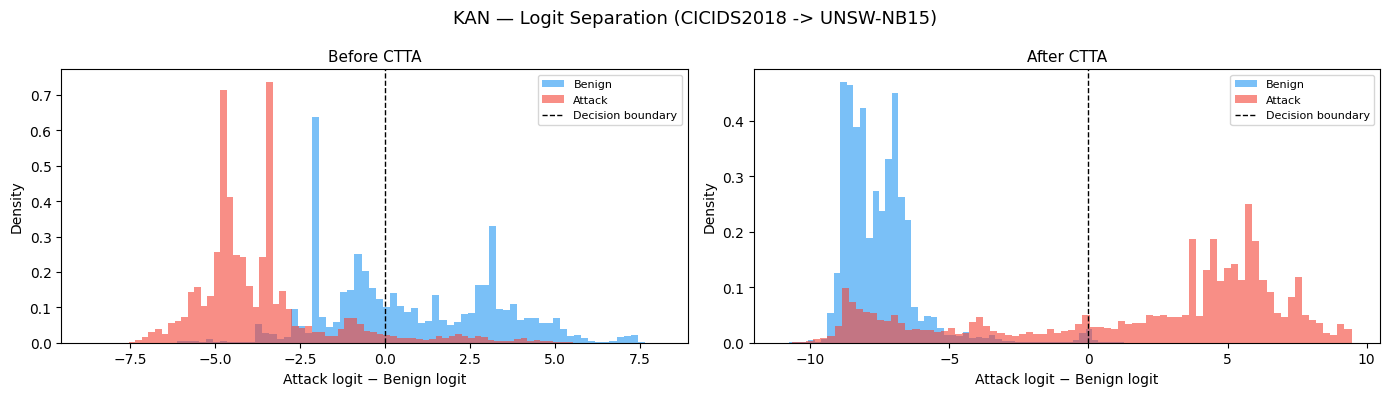

[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[CTTA] Stream complete.
[Pretrained TRAIN-ALL CTTA FINAL UNSW-NB15] F1: 0.8854 | Acc: 0.9885
[Few-shot/all-params] updating 16 tensors (103810 params).
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[Few-shot (all-params, kan)] F1: 0.8955 | Acc: 0.9897
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[CTTA] Stream complete.
[Scratch CTTA FINAL UNSW-NB15] F1: 0.9032 | Acc: 0.9902
[Scratch] few-shot 0.8955 | CTTA stream 0.8981 | CTTA final 0.9032


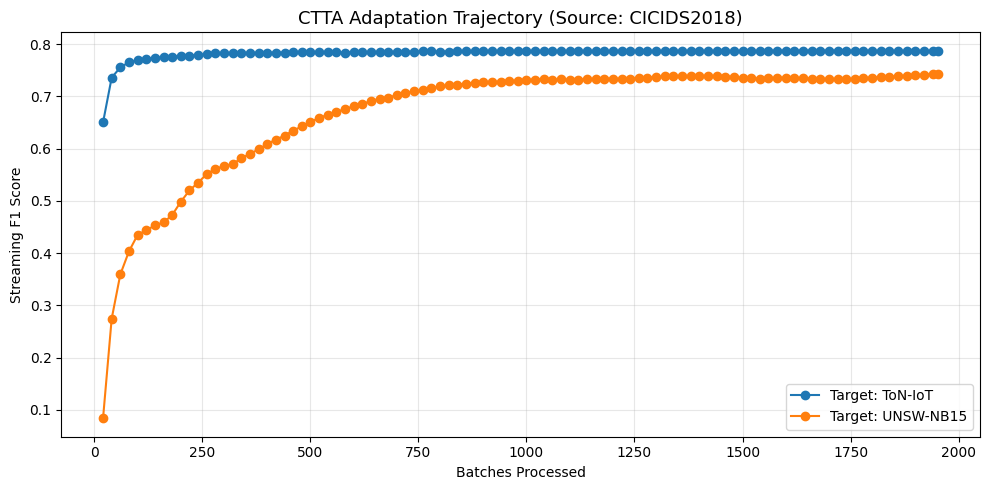

EXPERIMENT | Arch: KAN | Source: ToN-IoT
--------------------------------------------------------------------------------

[2026-07-24 08:57:19] [Step 1] load data set
[Data] Loading seyhed/nf-ton-iot-v3 ...
   -> Shape: (1000000, 49) | Attack rate: 38.97%
--------------------------------------------------------------------------------

[2026-07-24 08:57:25] [Step 2] SOURCE PRE-TRAINING (ToN-IoT) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | CTTA-trainable params=20,610

   [criterion] weighted CE | weights=[benign 0.82, attack 1.28]
[Pretrain] Epoch 1/20 | Loss: 0.1987 | Acc: 0.9321
[Pretrain] Epoch 2/20 | Loss: 0.1685 | Acc: 0.9419
[Pretrain] Epoch 3/20 | Loss: 0.1653 | Acc: 0.9429
[Pretrain] Epoch 4/20 | Loss: 0.1638 | Acc: 0.9436
[Pretrain] Epoch 5/20 | Loss: 0.1629 | Acc: 0.9435
[Pretrain] Epoch 6/20 | Loss: 0.1620 | Acc: 0.9438
[Pretrain] Epoch 7/20 | Loss: 0.1615 | Acc: 0.9441
[Pretrain] Epoch 8/20 | Loss: 0.1611 | Acc: 0.9441
[Pretrain] Epoch 9/20 | 

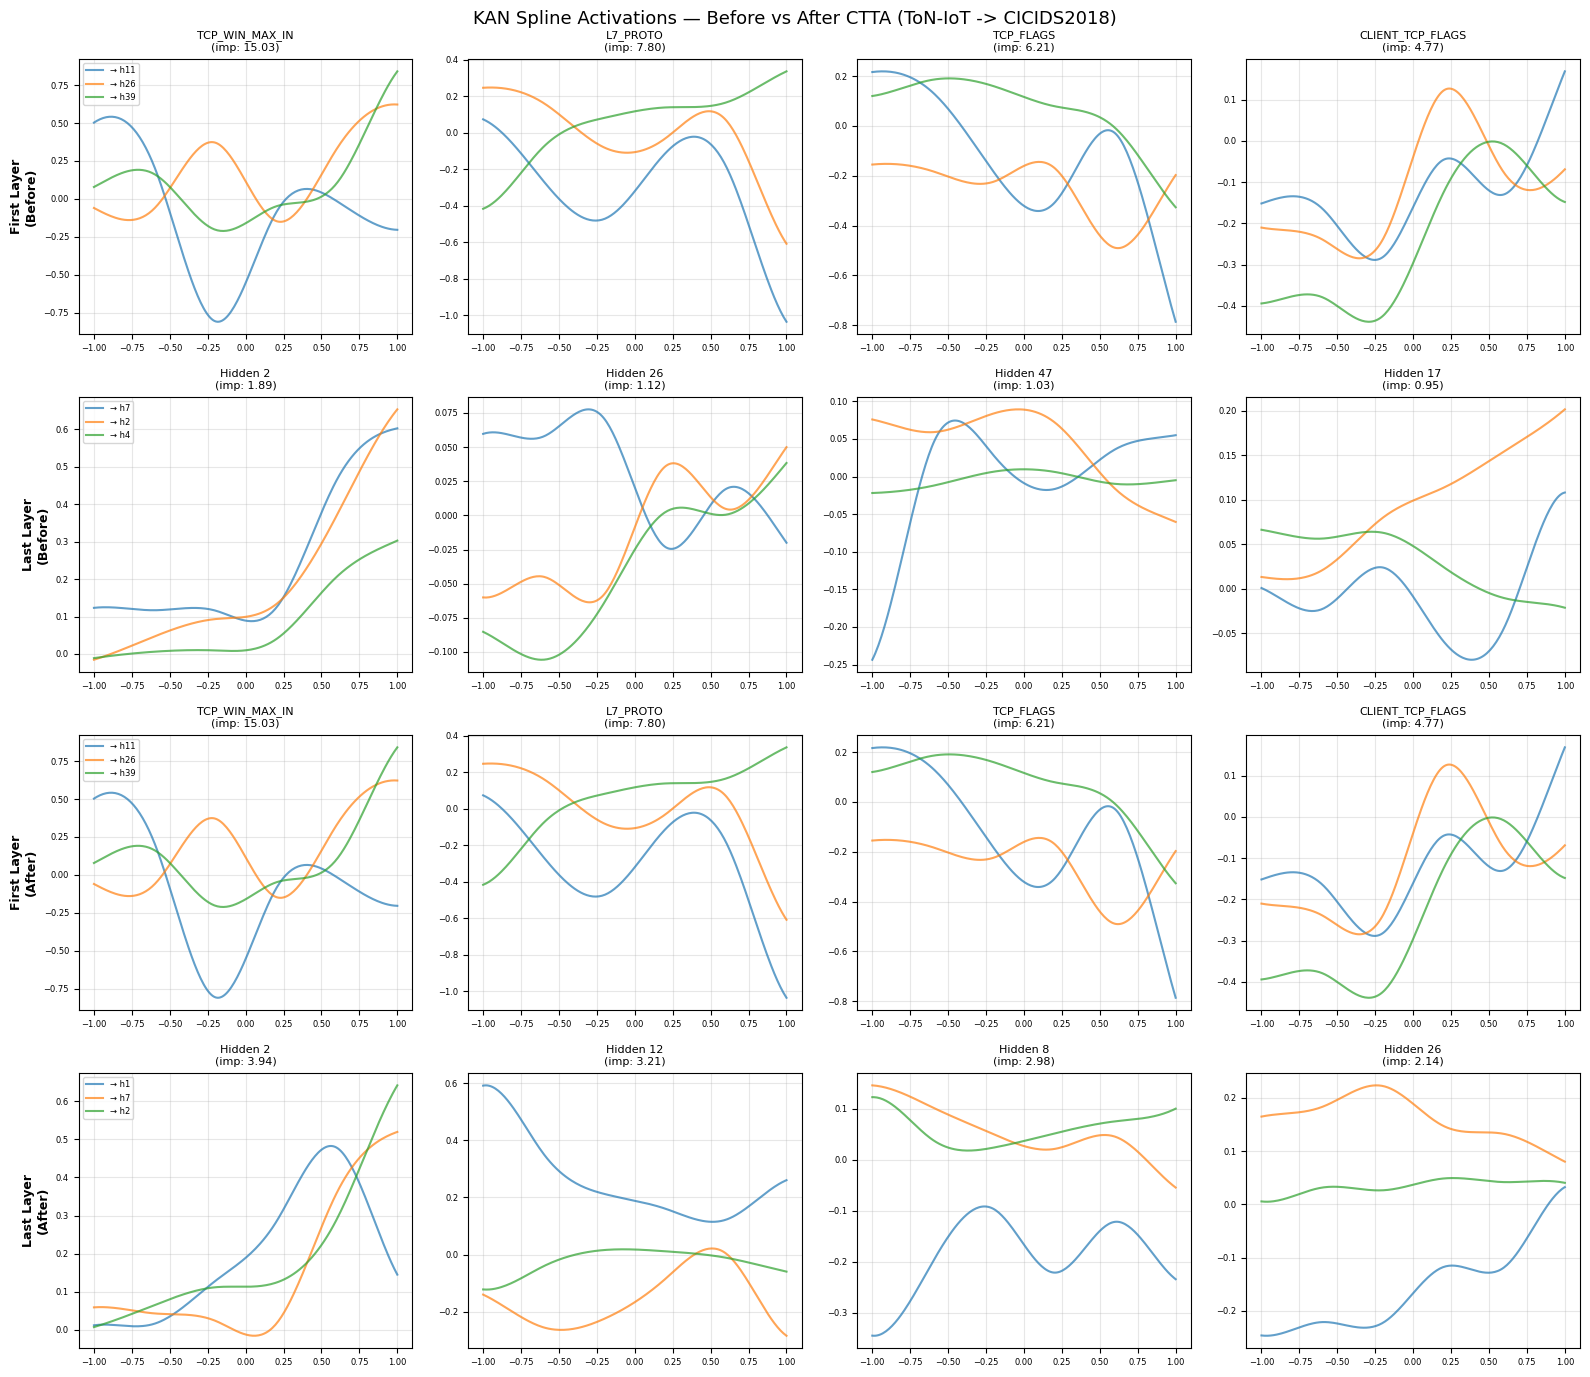

[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[CTTA] Stream complete.
[Pretrained TRAIN-ALL CTTA FINAL CICIDS2018] F1: 0.8843 | Acc: 0.9713
[Few-shot/all-params] updating 16 tensors (103810 params).
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Few-shot (all-params, kan)] F1: 0.8193 | Acc: 0.9512
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[CTTA] Stream complete.
[Scratch CTTA FINAL CICIDS2018] F1: 0.8788 | Acc: 0.9698
[Scratch] few-shot 0.8193 | CTTA stream 0.8668 | CTTA final 0.8788

[2026-07-24 09:18:35] [Step 3] 
---  Executing | Arch: KAN | Source: ToN-IoT -> Target: UNSW-NB15 ---
[Data] Loading seyhed/nf-unsw-nb15-v3 ...
   -> Shape: (100000

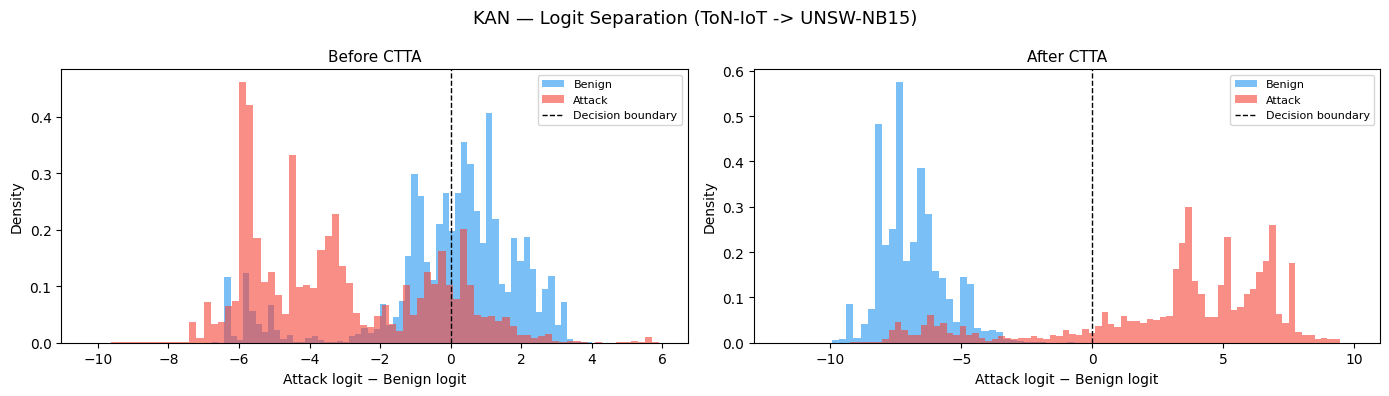

[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[CTTA] Stream complete.
[Pretrained TRAIN-ALL CTTA FINAL UNSW-NB15] F1: 0.8896 | Acc: 0.9890
[Few-shot/all-params] updating 16 tensors (103810 params).
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[Few-shot (all-params, kan)] F1: 0.8640 | Acc: 0.9869
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.53, attack 10.00]
[CTTA] Stream complete.
[Scratch CTTA FINAL UNSW-NB15] F1: 0.9072 | Acc: 0.9907
[Scratch] few-shot 0.8640 | CTTA stream 0.9069 | CTTA final 0.9072
EXPERIMENT | Arch: KAN | Source: UNSW-NB15
--------------------------------------------------------------------------------

[2026-07-24 09:32:28] [Step 1] load dat

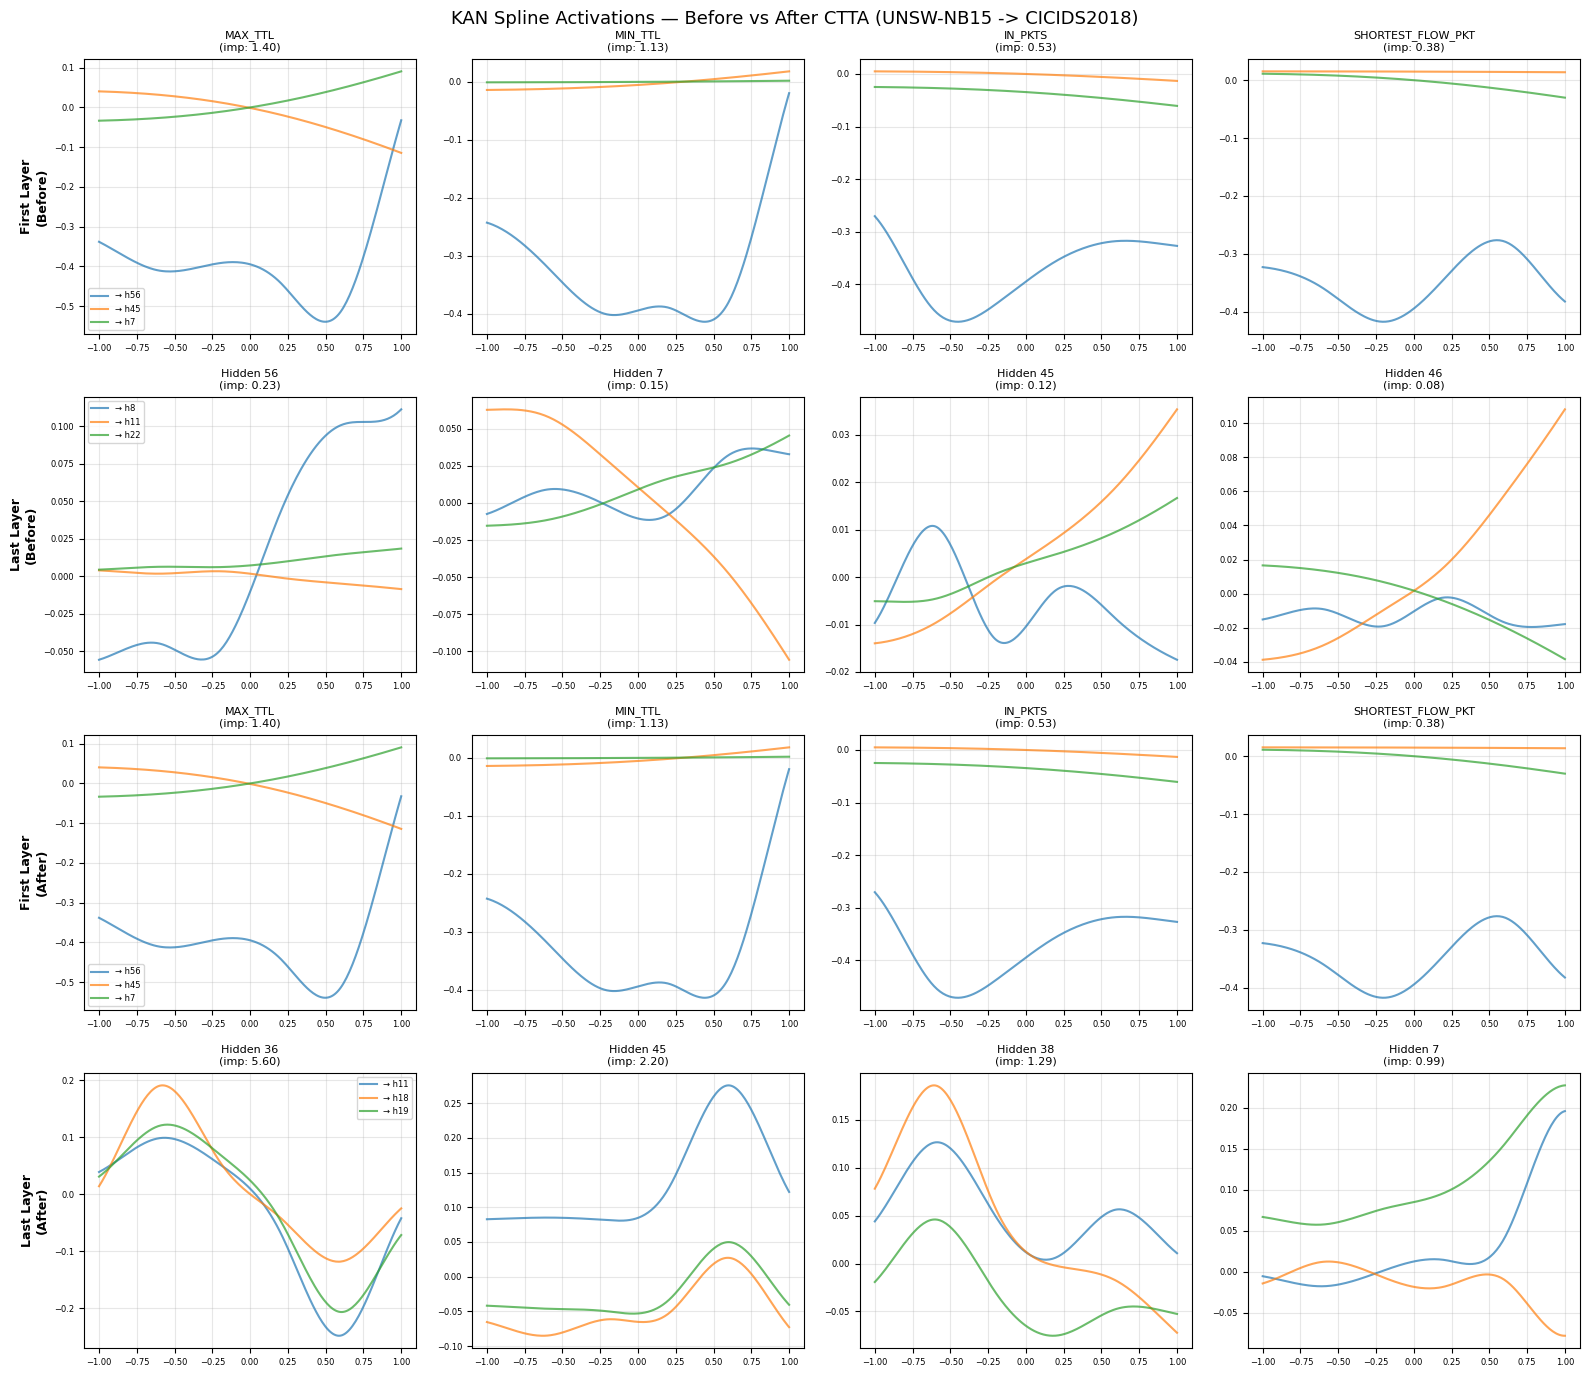

[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[CTTA] Stream complete.
[Pretrained TRAIN-ALL CTTA FINAL CICIDS2018] F1: 0.8626 | Acc: 0.9656
[Few-shot/all-params] updating 16 tensors (103810 params).
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Few-shot (all-params, kan)] F1: 0.8334 | Acc: 0.9570
[CTTA] TRAIN-ALL mode: all parameters trainable (scratch baseline).
[CTTA] Updating 16 param tensors (103810 params). All other weights frozen.
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[CTTA] Stream complete.
[Scratch CTTA FINAL CICIDS2018] F1: 0.8434 | Acc: 0.9601
[Scratch] few-shot 0.8334 | CTTA stream 0.8306 | CTTA final 0.8434

[2026-07-24 09:54:51] [Step 3] 
---  Executing | Arch: KAN | Source: UNSW-NB15 -> Target: ToN-IoT ---
[Data] Loading seyhed/nf-ton-iot-v3 ...
   -> Shape: (1000000,

,Architecture,Source,Target,Zero-Shot F1,Few-Shot F1 (spline),Few-Shot F1 (full),CTTA F1 stream (spline),CTTA F1 stream (full),CTTA F1 final (spline),CTTA F1 final (full),...,Scratch Few-Shot F1,Scratch CTTA F1 stream,Scratch CTTA F1 final,Pretrained TrainAll CTTA F1 final,Src F1 pre,Src F1 after (spline),Src F1 after (full),CTTA F1 final (no AGSA),Src F1 after (no AGSA),Retention Penalty
0,kan,CICIDS2018,ToN-IoT,0.439377,0.812528,0.847967,0.787082,0.798250,0.777070,0.795124,...,0.830417,0.807895,0.809479,0.810565,0.967876,0.450539,0.506530,0.781916,0.350190,0.000462
1,kan,CICIDS2018,UNSW-NB15,0.012037,0.506582,0.846295,0.742439,0.857533,0.788334,0.861292,...,0.895538,0.898083,0.903189,0.885450,0.967876,0.663137,0.259599,0.793140,0.570680,0.000609
2,kan,ToN-IoT,CICIDS2018,0.170592,0.731027,0.777553,0.834897,0.839042,0.862646,0.855455,...,0.819286,0.866765,0.878828,0.884337,0.929352,0.751084,0.460396,0.864763,0.726206,0.000435
3,kan,ToN-IoT,UNSW-NB15,0.027414,0.679493,0.895684,0.811056,0.882936,0.903832,0.931497,...,0.863955,0.906859,0.907212,0.889551,0.929352,0.655782,0.495168,0.894035,0.700203,0.000628
4,kan,UNSW-NB15,CICIDS2018,0.310688,0.599133,0.802046,0.635406,0.816783,0.587896,0.792121,...,0.833357,0.830593,0.843398,0.862583,0.998532,0.446124,0.022150,0.691488,0.758380,0.000020
5,kan,UNSW-NB15,ToN-IoT,0.532386,0.815032,0.811056,0.802838,0.792408,0.839083,0.776891,...,0.744405,0.800316,0.807278,0.807102,0.998532,0.109233,0.096376,0.842035,0.132649,0.000116
6,cnn,CICIDS2018,ToN-IoT,0.284832,0.755051,0.839154,0.754381,0.751123,0.738555,0.707777,...,0.843993,0.804878,0.804292,0.811842,0.965892,0.371689,0.503198,NaN,NaN,NaN
7,cnn,CICIDS2018,UNSW-NB15,0.012793,0.135519,0.653534,0.825751,0.837641,0.873849,0.758890,...,0.854970,0.913077,0.971631,0.886617,0.965892,0.014841,0.155135,NaN,NaN,NaN
8,cnn,ToN-IoT,CICIDS2018,0.267081,0.590057,0.745224,0.779773,0.800284,0.811893,0.801473,...,0.760628,0.844919,0.849986,0.849241,0.923995,0.638473,0.600421,NaN,NaN,NaN
9,cnn,ToN-IoT,UNSW-NB15,0.088375,0.434562,0.632304,0.671478,0.669777,0.740744,0.684066,...,0.765017,0.870318,0.877725,0.885393,0.923995,0.523086,0.190370,NaN,NaN,NaN


,Architecture,Source,Target,Table,Config,F1
0,kan,CICIDS2018,ToN-IoT,T3-trainable,Spline-only,0.787082
1,kan,CICIDS2018,ToN-IoT,T3-trainable,Splines + norm,0.792980
2,kan,CICIDS2018,ToN-IoT,T3-trainable,Splines + classifier,0.789348
3,kan,CICIDS2018,ToN-IoT,T3-trainable,Splines + norm + classifier,0.789718
4,kan,CICIDS2018,ToN-IoT,T3-trainable,Last KAN layer (incl. base path),0.800012
...,...,...,...,...,...,...
61,kan,UNSW-NB15,ToN-IoT,T4-loss,CE + ent + recon,0.803138
62,kan,UNSW-NB15,ToN-IoT,T4-loss,CE + ent only,0.807283
63,kan,UNSW-NB15,ToN-IoT,T4-loss,CE + recon only,0.800054
64,kan,UNSW-NB15,ToN-IoT,T4-loss,CE only,0.806571


In [14]:
architectures = ['kan', 'cnn', 'tab']
datasets = {
    'CICIDS2018': 'seyhed/nf-cicids2018-v3',
    'ToN-IoT': 'seyhed/nf-ton-iot-v3',
    'UNSW-NB15': 'seyhed/nf-unsw-nb15-v3'
}

results = []
ablation_results = []   # MOD: persisted Table 3/4 rows (were print-only before)

for arch in architectures:
    for src_name, src_path in datasets.items():
        # FIX: re-seed at the top of every (arch, source) config so each run is
        # independent of everything that executed before it. Previously the RNG
        # state at model init / shuffling depended on the whole prior history.
        seed_everything(SEED)

        print('=' * 80)
        print(f'EXPERIMENT | Arch: {arch.upper()} | Source: {src_name}')
        print('-' * 80)

        log_step(1,f'load data set')
        # 1. Load Source
        X_src, y_src, feature_names = load_dataset(src_path, sample_n=SAMPLE_N)
        input_dim = X_src.shape[1]
        loader_src_train, loader_src_test, source_scaler = make_source_loaders(X_src, y_src)
        del X_src, y_src; gc.collect()

        # 2. Pre-train Model
        model = run_phase1_pretraining(arch, src_name, input_dim,
                                       loader_src_train, device,
                                       PRETRAIN_EPOCHS, LATENT_DIM)

        # Save post-pretrain state
        model_state = {k: v.clone() for k, v in model.state_dict().items()}

        # FIX: Fisher information depends only on (arch, source) — it was being
        # recomputed identically for every target (a full pass over 200k
        # samples each time). Hoisted out of the target loop.
        kan_ret = None
        if arch == 'kan':
            model.load_state_dict(model_state)
            params_to_protect = get_spline_only_params(model) if SPLINE_TRUE \
                                else get_trainable_params(model)
            kan_ret = KAN_Retention(model, loader_src_test, device, params_to_protect)

        # 3. Determine Targets
        targets = {k: v for k, v in datasets.items() if k != src_name}
        trajectories = {}

        for tgt_name, tgt_path in targets.items():
         
            log_step(3,f'\n---  Executing | Arch: {arch.upper()} | '
                  f'Source: {src_name} -> Target: {tgt_name} ---')

            # FIX (critical): align the target's feature schema to the source's
            # so scaler + model always see the same features in the same order.
            X_tgt, y_tgt, _ = load_dataset(tgt_path, sample_n=SAMPLE_N,
                                           align_to=list(feature_names))

            # Using source scaler for consistency (deployment-realistic)
            pool_tgt_src_sc, stream_tgt_src_sc = make_target_loaders(
                X_tgt, y_tgt, external_scaler=source_scaler)
            del X_tgt, y_tgt; gc.collect()

            # Zero-shot Baseline
            log_step(4,f'zero shot')
            model.load_state_dict(model_state)
            zero_shot_f1 = run_phase2_zeroshot(model, stream_tgt_src_sc, tgt_name, device)

            # MOD: source performance before any adaptation — the reference
            # point for the forgetting/retention analysis below.
            src_f1_pre = evaluate(model, loader_src_test, device,
                                  desc=f'Source {src_name} (pre-CTTA)')


            # MOD: step-matched few-shot — same optimizer-step budget as CTTA
            # (len(stream_loader) * TTA_STEPS steps total), so stream access is
            # the only remaining difference between the two methods.
            if FEW_SHOT_MATCH_STEPS:
                import math
                fs_epochs = max(1, math.ceil(len(stream_tgt_src_sc) * TTA_STEPS
                                             / max(len(pool_tgt_src_sc), 1)))
            else:
                fs_epochs = 20
            print(f'[Few-shot] step-matched epochs = {fs_epochs} '
                  f'({fs_epochs * len(pool_tgt_src_sc)} steps vs CTTA '
                  f'{len(stream_tgt_src_sc) * TTA_STEPS})')

            # Few-shot baselines
            log_step(5,f'few shot')
            few_shot_spline_f1 = few_shot_baseline(
                model_state, pool_tgt_src_sc, stream_tgt_src_sc,
                input_dim, arch, device, spline_only=True,
                epochs=fs_epochs)     # param-matched control
            few_shot_full_f1 = few_shot_baseline(
                model_state, pool_tgt_src_sc, stream_tgt_src_sc,
                input_dim, arch, device, spline_only=False,
                epochs=fs_epochs)    # full-capacity reference

            # CTTA
            log_step(6,f'CTTA')
            model.load_state_dict(model_state)

            if arch == 'kan':
                print('===Type B Ablation===')
                # MOD: ablation results are now RETURNED and persisted, not
                # just printed — previously Tables 3/4 lived only in stdout
                # and were lost when the notebook output scrolled away.
                abl_rows = TypeBAblation().run(model, tgt_name,
                                               stream_tgt_src_sc, pool_tgt_src_sc)
                for r in abl_rows:
                    r.update({'Architecture': arch, 'Source': src_name})
                ablation_results.extend(abl_rows)
                model.load_state_dict(model_state)   # FIX: explicit reset — do not
                # rely on the ablation's internal restore for the headline run.

            # MOD: run BOTH CTTA modes so the final table reports spline-only
            # and full side by side (previously only the SPLINE_TRUE mode was
            # recorded). Both runs start from identical model AND RNG state so
            # they see the same pool shuffling / stochastic-restore draws —
            # the mode is the only difference. The SPLINE_TRUE (headline) mode
            # runs LAST so downstream visualisations and the retention penalty
            # reflect its adapted state, exactly as before.
            ctta = {}
            headline = 'spline' if SPLINE_TRUE else 'full'
            mode_order = [('full', False), ('spline', True)] if SPLINE_TRUE \
                         else [('spline', True), ('full', False)]
            rng_ckpt  = torch.get_rng_state()
            cuda_ckpt = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

            for mode_name, sp in mode_order:
                torch.set_rng_state(rng_ckpt)
                if cuda_ckpt is not None:
                    torch.cuda.set_rng_state_all(cuda_ckpt)
                model.load_state_dict(model_state)
                preds_m, labels_m, traj_m = run_ctta(
                    model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                    spline_only=sp,
                    ewc=kan_ret, ewc_lambda=EWC_LAMBDA,
                )
                # MOD: post-adaptation ('final') evaluation — re-score the full
                # stream with the final adapted model. Legitimate (no stream
                # labels were ever used in training) and comparable one-to-one
                # with the frozen few-shot baseline: streaming F1 carries the
                # burn-in penalty of early unadapted batches, final F1 measures
                # the model CTTA actually produced. The gap between the two IS
                # the burn-in cost.
                final_f1 = evaluate(model, stream_tgt_src_sc, device,
                                    desc=f'CTTA/{mode_name} FINAL {tgt_name}')
                # MOD: source retention — how much source performance survived
                # adaptation. Compare against src_f1_pre.
                src_after = evaluate(model, loader_src_test, device,
                                     desc=f'Source {src_name} after CTTA/{mode_name}')
                ctta[mode_name] = {
                    'f1':   f1_score(labels_m, preds_m, zero_division=0),
                    'acc':  accuracy_score(labels_m, preds_m),
                    'final_f1': final_f1,
                    'src_after': src_after,
                    'traj': traj_m,
                }
                print(f'[CTTA/{mode_name}] {tgt_name} - '
                      f'stream F1: {ctta[mode_name]["f1"]:.4f} | '
                      f'final F1: {final_f1:.4f} | '
                      f'Acc: {ctta[mode_name]["acc"]:.4f}')

            # MOD (AGSA validation): rerun the headline mode with the gate OFF
            # from identical weights + RNG. Two numbers fall out: target F1
            # without AGSA (claim: no cost) and source F1 after adaptation
            # without AGSA (claim: AGSA protects source knowledge).
            agsa_off = {}
            if AGSA_ABLATION and arch == 'kan':
                torch.set_rng_state(rng_ckpt)
                if cuda_ckpt is not None:
                    torch.cuda.set_rng_state_all(cuda_ckpt)
                model.load_state_dict(model_state)
                preds_n, labels_n, _ = run_ctta(
                    model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                    spline_only=SPLINE_TRUE,
                    ewc=kan_ret, ewc_lambda=EWC_LAMBDA,
                    spline_gate=False,
                )
                agsa_off = {
                    'f1': f1_score(labels_n, preds_n, zero_division=0),
                    'final_f1': evaluate(model, stream_tgt_src_sc, device,
                                         desc=f'CTTA no-AGSA FINAL {tgt_name}'),
                    'src_after': evaluate(model, loader_src_test, device,
                                          desc=f'Source {src_name} after no-AGSA'),
                }
                print(f'[AGSA ablation] gate ON  -> tgt(final) '
                      f'{ctta[headline]["final_f1"]:.4f} | src-after '
                      f'{ctta[headline]["src_after"]:.4f}')
                print(f'[AGSA ablation] gate OFF -> tgt(final) '
                      f'{agsa_off["final_f1"]:.4f} | src-after '
                      f'{agsa_off["src_after"]:.4f} | src-pre {src_f1_pre:.4f}')
                # restore the headline-mode adapted state for visualizations
                torch.set_rng_state(rng_ckpt)
                if cuda_ckpt is not None:
                    torch.cuda.set_rng_state_all(cuda_ckpt)
                model.load_state_dict(model_state)
                run_ctta(model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                         spline_only=SPLINE_TRUE,
                         ewc=kan_ret, ewc_lambda=EWC_LAMBDA)

            trajectories[tgt_name] = ctta[headline]['traj']

            retention_val = None
            if arch == 'kan':
                with torch.no_grad():          # FIX: diagnostic — no graph needed
                    retention_val = kan_ret.penalty().item()
                print(f'[KAN Retention] Penalty ({headline}): {retention_val:.4f}')
                run_all_visualizations(model_state, model, stream_tgt_src_sc,
                                       pool_tgt_src_sc, src_name, tgt_name,
                                       device, feature_names)

            # MOD (scratch baseline): same objectives and step budget, but
            # starting from a RANDOM init instead of the pretrained source
            # model, training all parameters. Quantifies what source
            # pretraining is worth. AGSA off (activation gating presumes a
            # source function worth protecting) and stochastic restore off
            # (pulling toward a random init would fight learning).
            scratch = {}
            if SCRATCH_BASELINE:
                # MOD: pretrained + train-all — differs from scratch-CTTA below
                # ONLY in starting weights (same all-params, gate off, restore
                # off), cleanly isolating the value of the pretrained init from
                # the capacity confound (20k vs 103k trainable params).
                torch.set_rng_state(rng_ckpt)
                if cuda_ckpt is not None:
                    torch.cuda.set_rng_state_all(cuda_ckpt)
                model.load_state_dict(model_state)
                preds_pa, labels_pa, _ = run_ctta(
                    model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                    spline_only=False, train_all=True,
                    spline_gate=False, restore_prob=0.0)
                scratch['pre_all_final'] = evaluate(
                    model, stream_tgt_src_sc, device,
                    desc=f'Pretrained TRAIN-ALL CTTA FINAL {tgt_name}')

                torch.set_rng_state(rng_ckpt)
                if cuda_ckpt is not None:
                    torch.cuda.set_rng_state_all(cuda_ckpt)
                rand_model = build_model(arch, input_dim).to(device)
                rand_state = {k: v.clone() for k, v in rand_model.state_dict().items()}
                # scratch few-shot: pool-only, all params, matched steps
                scratch['fs'] = few_shot_baseline(
                    rand_state, pool_tgt_src_sc, stream_tgt_src_sc,
                    input_dim, arch, device, spline_only=False,
                    epochs=fs_epochs, train_all=True)
                # scratch CTTA: same stream objectives, all params
                preds_r, labels_r, _ = run_ctta(
                    rand_model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                    spline_only=False, train_all=True,
                    spline_gate=False, restore_prob=0.0)
                scratch['stream'] = f1_score(labels_r, preds_r, zero_division=0)
                scratch['final']  = evaluate(rand_model, stream_tgt_src_sc, device,
                                             desc=f'Scratch CTTA FINAL {tgt_name}')
                print(f'[Scratch] few-shot {scratch["fs"]:.4f} | '
                      f'CTTA stream {scratch["stream"]:.4f} | '
                      f'CTTA final {scratch["final"]:.4f}')
                del rand_model, rand_state
                gc.collect()

            results.append({
                'Architecture': arch,
                'Source': src_name,
                'Target': tgt_name,
                'Zero-Shot F1': zero_shot_f1,
                'Few-Shot F1 (spline)': few_shot_spline_f1,
                'Few-Shot F1 (full)':   few_shot_full_f1,
                'CTTA F1 stream (spline)': ctta['spline']['f1'],
                'CTTA F1 stream (full)':   ctta['full']['f1'],
                'CTTA F1 final (spline)':  ctta['spline']['final_f1'],
                'CTTA F1 final (full)':    ctta['full']['final_f1'],
                'CTTA Acc (spline)': ctta['spline']['acc'],
                'CTTA Acc (full)':   ctta['full']['acc'],
                'Scratch Few-Shot F1':    scratch.get('fs'),
                'Scratch CTTA F1 stream': scratch.get('stream'),
                'Scratch CTTA F1 final':  scratch.get('final'),
                'Pretrained TrainAll CTTA F1 final': scratch.get('pre_all_final'),
                'Src F1 pre': src_f1_pre,
                'Src F1 after (spline)': ctta['spline']['src_after'],
                'Src F1 after (full)':   ctta['full']['src_after'],
                'CTTA F1 final (no AGSA)': agsa_off.get('final_f1'),
                'Src F1 after (no AGSA)':  agsa_off.get('src_after'),
                'Retention Penalty': retention_val
            })

        if arch == 'kan' and src_name == 'CICIDS2018':
            plot_adaptation_trajectory(trajectories, src_name)

        # MOD: free the model + loaders between configs (GPU memory hygiene)
        del model, model_state, loader_src_train, loader_src_test, kan_ret
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Display overall results
results_df = pd.DataFrame(results)
try:
    display(results_df)
except NameError:              # FIX: `display` exists only inside Jupyter
    print(results_df.to_string())
results_df.to_csv('grid_results.csv', index=False)   # MOD: persist results

# MOD: ablation tables (Table 3 / Table 4), persisted and displayed
if ablation_results:
    ablation_df = pd.DataFrame(ablation_results)[
        ['Architecture', 'Source', 'Target', 'Table', 'Config', 'F1']]
    try:
        display(ablation_df)
    except NameError:
        print(ablation_df.to_string())
    ablation_df.to_csv('ablation_results.csv', index=False)

## 9. Sequential CTTA — real-world domain sequences (truly CONTINUAL)

The grid above resets the model between targets (episodic TTA). This section
runs the deployment-realistic protocol: pretrain on a source, then adapt
through a SEQUENCE of target streams with NO reset — e.g. an NIDS deployed
on one network segment and later moved to another. After pretraining and
after each adaptation stage, the model is evaluated on EVERY domain (source
test set + each target stream), yielding the standard continual-learning
matrix from which average-F1 and per-domain forgetting can be read off.
Each variant (AGSA on/off) starts from identical weights AND RNG, so the
gate is the only difference.

In [15]:
RUN_SEQUENTIAL = True
SEQ_ARCHS      = ['kan']                      # add 'cnn'/'tab' for contrast
SEQUENCES      = [
    ('CICIDS2018', 'ToN-IoT', 'UNSW-NB15'),  # source, then targets in order
    ('UNSW-NB15', 'ToN-IoT', 'CICIDS2018'),
]
# Variant spec: replay = mix ALL previously-seen labelled pools into the CE
# term (the analyst who labelled 100 flows at each past site still has them —
# a near-free, deployment-honest assumption); gate = 'off' | 'stage'
# (per-stage AGSA, mass reset each domain) | 'cumulative' (NOVELTY: masks
# persist and freeze_current() folds each domain's activated coefficients
# into a protected set, partitioning the spline support across the sequence).
SEQ_VARIANTS = [
    {'name': 'AGSA per-stage',           'replay': False, 'gate': 'stage'},
    {'name': 'no AGSA',                  'replay': False, 'gate': 'off'},
    {'name': 'replay, no AGSA',          'replay': True,  'gate': 'off'},
    # MOD: completes the 2x2 (replay x gate) so endpoint gains can be
    # attributed between the two mechanisms instead of only their combination.
    {'name': 'replay + AGSA',            'replay': True,  'gate': 'stage'},
    {'name': 'replay + cumulative AGSA', 'replay': True,  'gate': 'cumulative'},
]

# MOD: fraction of each replay-pool epoch drawn from the CURRENT domain.
# A uniform union dilutes the current domain to 1/k at stage k, which was
# observed to cost ~15 F1 points on the final target; weighting restores the
# retention/plasticity dial. 0.5 = half current, half all past domains.
REPLAY_CURRENT_FRAC = 0.5


def build_replay_pool(current_pool, past_pools, current_frac=None):
    """
    MOD: replay pool = current domain's pool + all past domains' pools, with
    the current domain oversampled (by deterministic duplication) so it makes
    up ~current_frac of the mix. Uniform union (current_frac=None) dilutes the
    current domain to 1/k at stage k — observed to cost ~15 F1 on the final
    target; weighting restores plasticity while keeping full retention signal.
    """
    xs_p = torch.cat([l.dataset.tensors[0] for l in past_pools])
    ys_p = torch.cat([l.dataset.tensors[1] for l in past_pools])
    x_c, y_c = current_pool.dataset.tensors
    if current_frac is not None and len(past_pools) > 0:
        # duplicate current pool so n_current*k / (n_current*k + n_past) ~ frac
        k = max(1, int(round(current_frac / max(1e-9, 1 - current_frac)
                             * len(ys_p) / max(1, len(y_c)))))
        x_c = x_c.repeat(k, *([1] * (x_c.dim() - 1)))
        y_c = y_c.repeat(k)
    xs = torch.cat([x_c, xs_p])
    ys = torch.cat([y_c, ys_p])
    ds = TensorDataset(xs, ys)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                      generator=seeded_generator())


seq_results = []
if RUN_SEQUENTIAL:
    for seq_arch in SEQ_ARCHS:
        for seq in SEQUENCES:
            seq_src = seq[0]
            seed_everything(SEED)
            print('=' * 80)
            print(f'SEQUENTIAL | Arch: {seq_arch.upper()} | ' + ' -> '.join(seq))
            print('=' * 80)

            # Source pretraining
            X_s, y_s, seq_feat = load_dataset(datasets[seq_src], sample_n=SAMPLE_N)
            seq_input_dim = X_s.shape[1]
            seq_l_tr, seq_l_te, seq_scaler = make_source_loaders(X_s, y_s)
            # MOD: a 100-sample stratified SOURCE pool for replay variants —
            # the operator plainly retains a handful of labelled source flows,
            # and the dominant forgetting observed is source collapse, which
            # target-only replay cannot address.
            src_pool_n = max(int(round(len(y_s) * FEW_SHOT_RATIO)), MIN_POOL_SIZE)
            Xp_s, _, yp_s, _ = train_test_split(
                X_s, y_s, train_size=src_pool_n, random_state=SEED, stratify=y_s)
            Xp_s = seq_scaler.transform(Xp_s)
            seq_src_pool = DataLoader(
                TensorDataset(torch.from_numpy(Xp_s), torch.from_numpy(yp_s)),
                batch_size=BATCH_SIZE, shuffle=True, generator=seeded_generator())
            del X_s, y_s, Xp_s, yp_s; gc.collect()
            seq_model = run_phase1_pretraining(seq_arch, seq_src, seq_input_dim,
                                               seq_l_tr, device,
                                               PRETRAIN_EPOCHS, LATENT_DIM)
            seq_state = {k: v.clone() for k, v in seq_model.state_dict().items()}

            # Loaders for every target in the sequence (fresh 100-sample pool
            # per domain — the analyst labels a small batch at each new site)
            seq_pools, seq_streams = {}, {}
            for name in seq[1:]:
                X_t, y_t, _ = load_dataset(datasets[name], sample_n=SAMPLE_N,
                                           align_to=list(seq_feat))
                p, s = make_target_loaders(X_t, y_t, external_scaler=seq_scaler)
                seq_pools[name], seq_streams[name] = p, s
                del X_t, y_t; gc.collect()

            seq_rng  = torch.get_rng_state()
            seq_cuda = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

            for variant in SEQ_VARIANTS:
                var_name = variant['name']
                torch.set_rng_state(seq_rng)
                if seq_cuda is not None:
                    torch.cuda.set_rng_state_all(seq_cuda)
                seq_model.load_state_dict(seq_state)

                # NOVELTY (cumulative AGSA): persistent gates, built once per
                # variant on the layer(s) run_ctta will train, owned here.
                cum_gates = []
                if variant['gate'] == 'cumulative' and isinstance(seq_model, KanAEClassifier):
                    tp = get_spline_only_params(seq_model) if SPLINE_TRUE \
                         else get_trainable_params(seq_model)
                    tp_ids = {id(p) for p in tp}
                    for layer in seq_model.encoder.layers:
                        if any(id(p) in tp_ids for p in layer.parameters()):
                            try:
                                g = SplineActivationGate(layer)
                                g.capture = False   # FIX: no mass from the
                                cum_gates.append(g) # stage-0 evaluations
                            except ValueError:
                                pass

                def eval_all_domains(stage_label, extra=None):
                    # FIX: positional schema ('F1 source/target1/target2') so
                    # both sequences share columns — the old domain-named
                    # columns forced pandas to union them, leaving half of
                    # every row NaN and making the table look broken.
                    row = {'Architecture': seq_arch,
                           'Sequence': ' -> '.join(seq),
                           'Source': seq_src,
                           'Target1': seq[1],
                           'Target2': seq[2],
                           'Variant': var_name,
                           'Stage': stage_label}
                    row['F1 source'] = evaluate(
                        seq_model, seq_l_te, device,
                        desc=f'[{var_name}|{stage_label}] {seq_src} (source)')
                    for pos, name in enumerate(seq[1:], start=1):
                        row[f'F1 target{pos}'] = evaluate(
                            seq_model, seq_streams[name], device,
                            desc=f'[{var_name}|{stage_label}] {name}')
                    if extra:
                        row.update(extra)
                    seq_results.append(row)

                eval_all_domains(f'0: pretrain({seq_src})')

                # NO reset between stages — this is the continual protocol.
                # Replay variants start with the retained source pool.
                past_pools = [seq_src_pool] if variant['replay'] else []
                try:
                    for i, name in enumerate(seq[1:], start=1):
                        print(f'\n--- [{var_name}] Stage {i}: CTTA on {name} '
                              f'(no reset) ---')
                        current_pool = seq_pools[name]
                        if variant['replay']:
                            stage_pool = build_replay_pool(
                                current_pool, past_pools,
                                current_frac=REPLAY_CURRENT_FRAC)
                            print(f'[Replay] pool = current({name}) at '
                                  f'~{REPLAY_CURRENT_FRAC:.0%} + '
                                  f'{len(past_pools)} past domain(s) '
                                  f'({len(stage_pool.dataset)} samples)')
                        else:
                            stage_pool = current_pool
                        # entropy anchor always uses the CURRENT domain's rate
                        stage_prior = pool_prior(seq_pools[name], device)

                        run_ctta(seq_model, seq_streams[name], stage_pool,
                                 device, spline_only=SPLINE_TRUE,
                                 spline_gate=(False if variant['gate'] == 'off'
                                              else None),
                                 prior=stage_prior,
                                 external_gates=(cum_gates or None)
                                                if variant['gate'] == 'cumulative'
                                                else None)

                        extra = None
                        if variant['gate'] == 'cumulative' and cum_gates:
                            fracs = []
                            for gi, g in enumerate(cum_gates):
                                cov = g.coverage()
                                pf = g.freeze_current()
                                fracs.append(pf)
                                print(f'[Cumulative AGSA] layer {gi}: '
                                      f'{cov:.1%} active this stage; '
                                      f'{pf:.1%} now protected (owned by '
                                      f'domains seen so far).')
                            extra = {'Protected frac': float(np.mean(fracs))}
                        past_pools.append(current_pool)   # becomes 'past' now
                        eval_all_domains(f'{i}: after CTTA {name}', extra=extra)
                finally:
                    for g in cum_gates:
                        g.remove()

            del seq_model, seq_state, seq_pools, seq_streams, seq_l_tr, seq_l_te, seq_src_pool
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    seq_df = pd.DataFrame(seq_results)
    try:
        display(seq_df)
    except NameError:
        print(seq_df.to_string())
    seq_df.to_csv('sequential_results.csv', index=False)

SEQUENTIAL | Arch: KAN | CICIDS2018 -> ToN-IoT -> UNSW-NB15
[Data] Loading seyhed/nf-cicids2018-v3 ...
   -> Shape: (1000000, 49) | Attack rate: 12.98%
--------------------------------------------------------------------------------

[2026-07-24 11:41:43] [Step 2] SOURCE PRE-TRAINING (CICIDS2018) | KAN
[Model] kan | input_dim=49 | latent_dim=32 | total params=103,810 | CTTA-trainable params=20,610

   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Pretrain] Epoch 1/20 | Loss: 0.1196 | Acc: 0.9886
[Pretrain] Epoch 2/20 | Loss: 0.1010 | Acc: 0.9910
[Pretrain] Epoch 3/20 | Loss: 0.0986 | Acc: 0.9912
[Pretrain] Epoch 4/20 | Loss: 0.0972 | Acc: 0.9912
[Pretrain] Epoch 5/20 | Loss: 0.0963 | Acc: 0.9913
[Pretrain] Epoch 6/20 | Loss: 0.0961 | Acc: 0.9914
[Pretrain] Epoch 7/20 | Loss: 0.0959 | Acc: 0.9914
[Pretrain] Epoch 8/20 | Loss: 0.0956 | Acc: 0.9915
[Pretrain] Epoch 9/20 | Loss: 0.0953 | Acc: 0.9915
[Pretrain] Epoch 10/20 | Loss: 0.0952 | Acc: 0.9915
[Pretrain] Epoch 11/20 

,Architecture,Sequence,Source,Target1,Target2,Variant,Stage,F1 source,F1 target1,F1 target2,Protected frac
0,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,AGSA per-stage,0: pretrain(CICIDS2018),0.967876,0.439377,0.012037,NaN
1,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,AGSA per-stage,1: after CTTA ToN-IoT,0.450539,0.777070,0.083831,NaN
2,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,AGSA per-stage,2: after CTTA UNSW-NB15,0.306183,0.187162,0.823695,NaN
3,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,no AGSA,0: pretrain(CICIDS2018),0.967876,0.439377,0.012037,NaN
4,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,no AGSA,1: after CTTA ToN-IoT,0.350190,0.781916,0.074663,NaN
5,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,no AGSA,2: after CTTA UNSW-NB15,0.164989,0.162372,0.838532,NaN
6,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,"replay, no AGSA",0: pretrain(CICIDS2018),0.967876,0.439377,0.012037,NaN
7,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,"replay, no AGSA",1: after CTTA ToN-IoT,0.695787,0.770494,0.058032,NaN
8,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,"replay, no AGSA",2: after CTTA UNSW-NB15,0.810732,0.765741,0.460940,NaN
9,kan,CICIDS2018 -> ToN-IoT -> UNSW-NB15,CICIDS2018,ToN-IoT,UNSW-NB15,replay + AGSA,0: pretrain(CICIDS2018),0.967876,0.439377,0.012037,NaN
